# MODUL 4 MORFOLOGI CITRA

### MENGIMPOR LIBRARY

In [271]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

*Cell code* di atas digunakan untuk memuat tiga library fundamental yang akan mendukung seluruh proses perbaikan citra dan deteksi tepi dalam modul ini. Library **OpenCV (`cv2`)** berperan sebagai alat utama untuk operasi *low-level* pengolahan citra, seperti pembacaan file gambar dan transformasi ruang warna. Library **NumPy** digunakan untuk menangani representasi citra dalam bentuk array multidimensi, yang sangat krusial saat melakukan perhitungan matematis pada piksel atau ketika membangun kernel filter khusus untuk proses perbaikan kualitas citra. Sementara itu, library **Matplotlib (`plt`)** berfungsi sebagai media visualisasi untuk menampilkan perbandingan antara citra asli dan citra hasil pemrosesan secara berdampingan melalui pembuatan plot atau *grid* gambar.

### MELAKUKAN DEKLARASI DAN INISIALISASI KERNEL

#### KERNEL DARI JURNAL MODUL 4

In [272]:
kernel_diamond = np.array(
    [
        [0,0,1,0,0], 
        [0,1,1,1,0], 
        [1,1,1,1,1], 
        [0,1,1,1,0], 
        [0,0,1,0,0] 
    ],
    dtype=np.float32,
) 
 
kernel_cross = np.array(
    [
        [0,1,0], 
        [1,1,1], 
        [0,1,0] 
    ],
    dtype=np.float32
) 
 
kernel_x = np.array(
    [
        [1,0,0,0,1], 
        [0,1,0,1,0], 
        [0,0,1,0,0], 
        [0,1,0,1,0], 
        [1,0,0,0,1] 
    ],
    dtype=np.float32
)

*Cell code* di atas digunakan untuk mendeklarasikan dan menginisialisasi tiga buah matriks biner, yaitu `kernel_diamond`, `kernel_cross`, dan `kernel_x`, yang akan bertindak sebagai elemen penstruktur (*structuring element*) dalam mengeksekusi berbagai operasi morfologi citra seperti dilasi, erosi, *opening*, maupun *closing*. Secara teknis, setiap *kernel* dibangun menggunakan *NumPy array* dengan representasi nilai spesifik (0 dan 1) untuk membentuk karakteristik geometri yang berbeda yang mana pola belah ketupat 5x5 pada `kernel_diamond` ideal untuk pemrosesan objek melingkar yang halus, pola salib 3x3 pada `kernel_cross` diandalkan untuk manipulasi tepi ortogonal standar, dan pola silang diagonal 5x5 pada `kernel_x` difokuskan untuk memperkuat fitur sudut atau struktur berorientasi miring. Pendefinisian parameter tipe data `dtype=np.uint8` di akhir inisialisasi sangat krusial untuk memastikan bahwa alokasi memori matriks berada dalam format *8-bit unsigned integer*, sehingga kompatibel dan efisien saat diaplikasikan sebagai filter pembanding yang bergeser (*sliding window*) di atas permukaan piksel citra biner target.

#### KERNEL UNTUK PERMASALAHAN SOAL JURNAL

In [273]:
kernel_fullsatu_3X3 = np.array(
    [
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ],
    dtype=np.float32,
)

kernel_fullsatu_5X5 = np.array(
    [
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
    ],
    dtype=np.float32,
)

*Cell code* di atas berfungsi untuk mendeklarasikan dan menginisialisasi dua buah matriks filter homogen berukuran ganjil, yaitu `kernel_fullsatu_3X3` dan `kernel_fullsatu_5X5`, yang akan digunakan sebagai instrumen utama dalam menyelesaikan studi kasus pemrosesan spasial pada modul ini. Secara teknis, kedua *kernel* dikonfigurasi menggunakan fungsi `np.array()` dengan mengisi seluruh elemen matriks menggunakan nilai seragam, yaitu angka 1, yang merepresentasikan elemen penstruktur penuh (*full-structuring element*) tanpa orientasi arah tertentu. Karakteristik matriks yang diisi penuh oleh nilai 1 ini membuatnya sangat fleksibel untuk diaplikasikan pada dua operasi fundamental, baik sebagai filter lolos rendah (*low-pass filter*) dalam meratakan atau menghaluskan (*smoothing*) intensitas piksel tetangga jika nantinya dikombinasikan dengan faktor pembagi normalisasi, maupun sebagai elemen penstruktur masif untuk memperluas geometri objek biner secara seragam dalam operasi morfologi dilasi. Penentuan parameter tipe data `dtype=np.float32` pada akhir inisialisasi sangat krusial untuk menjaga presisi nilai pecahan dan mencegah terjadinya galat pembulatan (*truncation error*) saat matriks tersebut dilibatkan dalam kalkulasi akumulasi nilai piksel yang berulang selama proses konvolusi domain spasial.

#### KERNEL UNTUK DETEKSI TEPI

In [274]:
kernel_sobel_x = np.array(
    [
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ],
    dtype=np.float32,
)

kernel_sobel_y = np.array(
    [
        [ 1,  2,  1],
        [ 0,  0,  0],
        [-1, -2, -1]
    ],
    dtype=np.float32,
)

kernel_prewitt_x = np.array(
    [
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ],
    dtype=np.float32,
)

kernel_prewitt_y = np.array(
    [
        [ 1,  1,  1],
        [ 0,  0,  0],
        [-1, -1, -1]
    ],
    dtype=np.float32,
)

kernel_roberts_x = np.array(
    [
        [1,  0],
        [0, -1]
    ],
    dtype=np.float32,
)

kernel_roberts_y = np.array(
    [
        [ 0, 1],
        [-1, 0]
    ],
    dtype=np.float32,
)

Di dalam *cell code* ini, dilakukan pendefinisian dua buah *kernel* Sobel, yaitu `kernel_sobel_x` dan `kernel_sobel_y`, yang berfungsi sebagai operator turunan pertama untuk mendeteksi gradien intensitas piksel pada citra. `kernel_sobel_x` merupakan sebuah *array* yang dirancang untuk menekankan perbedaan intensitas secara horizontal guna mengekstraksi tepi-tepi vertikal, sementara `kernel_sobel_y` dikonfigurasi untuk menekankan perbedaan intensitas secara vertikal guna mendeteksi tepi-tepi horizontal. Kedua *kernel* ini menggunakan tipe data *float32* untuk menjaga presisi nilai selama operasi konvolusi, di mana hasil dari perhitungan gradien di kedua arah ini nantinya dapat dikombinasikan untuk menentukan magnitudo serta arah tepi pada objek di dalam citra digital secara akurat.

Pada *cell code* ini juga dilakukan konfigurasi dua buah matriks filter yang dikenal sebagai *kernel* Prewitt, yaitu `kernel_prewitt_x` dan `kernel_prewitt_y`, untuk kebutuhan ekstraksi fitur tepi pada citra digital. Serupa dengan *kernel* Sobel, *kernel* Prewitt beroperasi sebagai operator turunan orde pertama yang menghitung selisih intensitas piksel bertetangga, namun menggunakan bobot yang seragam (nilai 1) pada seluruh elemen aktifnya. `kernel_prewitt_x` dirancang untuk menghitung gradien pada arah horizontal guna menonjolkan tepi-tepi vertikal, sedangkan `kernel_prewitt_y` menghitung gradien pada arah vertikal guna menonjolkan tepi-tepi horizontal. Inisialisasi menggunakan *NumPy array* dengan tipe data *float32* memastikan setiap hasil operasi konvolusi memiliki presisi tinggi dalam merepresentasikan kekuatan gradien tepi sebelum dilakukan tahap ambang batas (*thresholding*) atau visualisasi akhir.

Selain itu, dalam *cell code* ini, dilakukan konfigurasi dua buah matriks filter yang dikenal sebagai *kernel* Prewitt, yaitu `kernel_prewitt_x` dan `kernel_prewitt_y`, untuk kebutuhan ekstraksi fitur tepi pada citra digital. Serupa dengan *kernel* Sobel, *kernel* Prewitt beroperasi sebagai operator turunan orde pertama yang menghitung selisih intensitas piksel bertetangga, namun menggunakan bobot yang seragam (nilai 1) pada seluruh elemen aktifnya. `kernel_prewitt_x` dirancang untuk menghitung gradien pada arah horizontal guna menonjolkan tepi-tepi vertikal, sedangkan `kernel_prewitt_y` menghitung gradien pada arah vertikal guna menonjolkan tepi-tepi horizontal. Inisialisasi menggunakan *NumPy array* dengan tipe data *float32* memastikan setiap hasil operasi konvolusi memiliki presisi tinggi dalam merepresentasikan kekuatan gradien tepi sebelum dilakukan tahap ambang batas (*thresholding*) atau visualisasi akhir.

### MENDEKLARASIKAN FUNCTION YANG DIBUTUHKAN UNTUK PRAPEMROSESAN

In [275]:
def resize(citra, tinggi_baru, lebar_baru):
    tinggi_lama = citra.shape[0]
    lebar_lama = citra.shape[1]
    hasil = np.zeros((tinggi_baru, lebar_baru), dtype=citra.dtype)
    skala_baris = tinggi_lama / tinggi_baru
    skala_kolom = lebar_lama / lebar_baru
    for baris in range(tinggi_baru):
        for kolom in range(lebar_baru):
            baris_asal = int(baris * skala_baris)
            kolom_asal = int(kolom * skala_kolom)
            if baris_asal >= tinggi_lama:
                baris_asal = tinggi_lama - 1
            if kolom_asal >= lebar_lama:
                kolom_asal = lebar_lama - 1
            hasil[baris, kolom] = citra[baris_asal, kolom_asal]
    return hasil

*Cell code* di atas mendefinisikan fungsi `resize(citra, tinggi_baru, lebar_baru)` yang dirancang untuk mengubah dimensi spasial suatu citra digital secara manual menggunakan pendekatan interpolasi tetangga terdekat (*nearest-neighbor interpolation*). Algoritma ini bekerja dengan menginisialisasi matriks `hasil` berukuran dimensi baru menggunakan fungsi `np.zeros()` dengan mempertahankan konsistensi tipe data asli (`citra.dtype`), kemudian menghitung rasio pemetaan geometris melalui variabel `skala_baris` dan `skala_kolom`. Melalui tahapan perulangan bersarang, setiap koordinat piksel pada matriks target dipetakan kembali ke koordinat indeks asalnya (`baris_asal` dan `kolom_asal`) dengan melakukan operasi pemotongan nilai desimal menggunakan fungsi `int()`. Untuk mencegah terjadinya galat keluar dari batas matriks (*index out of bounds*) pada saat proses pemetaan ulang di area tepian kontur gambar, fungsi ini menerapkan logika pengondisian *clamping* yang secara teknis memaksa nilai indeks koordinat asal tetap berada pada batas maksimum dimensi citra lama. Pendekatan rekonstruksi matriks spasial ini sangat berguna untuk melakukan penyesuaian skala dimensi gambar secara cepat dan efisien tanpa mengubah nilai intensitas warna asli dari piksel terdekat yang disalinnya.

In [276]:
def konvolusi(citra, kernel):
    tinggi_citra = citra.shape[0]
    lebar_citra = citra.shape[1]
    ukuran_kernel = kernel.shape[0]
    kanvas = np.zeros((tinggi_citra, lebar_citra), dtype=np.float32)
    batas_kiri_atas = ukuran_kernel // 2
    if ukuran_kernel % 2 == 0:
        batas_kiri_atas = (ukuran_kernel - 1) // 2
    batas_kanan_bawah = ukuran_kernel - batas_kiri_atas
    for baris in range(tinggi_citra):
        for kolom in range(lebar_citra):
            total_konvolusi = 0.0
            for geser_baris in range(-batas_kiri_atas, batas_kanan_bawah):
                for geser_kolom in range(-batas_kiri_atas, batas_kanan_bawah):
                    baris_target = baris + geser_baris
                    kolom_target = kolom + geser_kolom
                    if (
                        0 <= baris_target < tinggi_citra
                        and 0 <= kolom_target < lebar_citra
                    ):
                        nilai_piksel = float(citra[baris_target, kolom_target])
                    else:
                        nilai_piksel = 0.0
                    indeks_baris_kernel = geser_baris + batas_kiri_atas
                    indeks_kolom_kernel = geser_kolom + batas_kiri_atas
                    bobot_kernel = kernel[
                        indeks_baris_kernel, indeks_kolom_kernel
                    ]
                    total_konvolusi += nilai_piksel * bobot_kernel
            kanvas[baris, kolom] = total_konvolusi
    return kanvas

*Cell code* di atas mendefinisikan fungsi `konvolusi(citra, kernel)` yang berfungsi untuk menerapkan komputasi filter spasial pada citra digital secara manual melalui mekanisme pergeseran matriks tetangga. Algoritma ini diawali dengan mengekstraksi dimensi spasial objek serta menentukan parameter `batas_kiri_atas` dan `batas_kanan_bawah` secara dinamis, yang secara teknis memungkinkannya untuk menangani *kernel* berukuran ganjil maupun genap tanpa memicu pergeseran indeks matriks (*indexing offset*). Menggunakan empat tingkatan kalang bersarang (*nested loops*), fungsi ini mengiterasi setiap koordinat piksel citra dan melakukan akumulasi perkalian antara intensitas lokal dengan bobot *kernel* yang bersesuaian ke dalam variabel `total_konvolusi`. Guna mengantisipasi fenomena *out-of-bounds* saat jendela operasi berada di area tepian luar kontur gambar, diimplementasikan logika pengkondisian batas (*boundary checking*) yang bertindak sebagai *zero padding* dengan memaksa nilai intensitas di luar matriks bernilai 0.0. Hasil komputasi linier berpresisi tinggi ini ditampung ke dalam objek `kanvas` bertipe `np.float32` sebelum dikembalikan sebagai citra luaran baru, menjadikannya fungsi prapemrosesan yang sangat krusial untuk mendukung fungsionalitas penajaman (*sharpening*), penghalusan (*smoothing*), maupun deteksi tepi pada tahapan pengerjaan jurnal selanjutnya.

In [277]:
def deteksi_tepi(citra, kernel_x, kernel_y):
    gradien_x = konvolusi(citra, kernel_x)
    gradien_y = konvolusi(citra, kernel_y)
    tinggi = citra.shape[0]
    lebar = citra.shape[1]
    magnitudo = np.zeros((tinggi, lebar), dtype=np.float32)
    nilai_maksimum = 0.0
    for baris in range(tinggi):
        for kolom in range(lebar):
            nilai_x = float(gradien_x[baris, kolom])
            nilai_y = float(gradien_y[baris, kolom])
            if nilai_x < 0:
                nilai_x = -nilai_x
            if nilai_y < 0:
                nilai_y = -nilai_y
            total_gradien = nilai_x + nilai_y
            magnitudo[baris, kolom] = total_gradien
            if total_gradien > nilai_maksimum:
                nilai_maksimum = total_gradien
    citra_hasil = np.zeros((tinggi, lebar), dtype=np.uint8)
    if nilai_maksimum > 0:
        for baris in range(tinggi):
            for kolom in range(lebar):
                nilai_normalisasi = (
                    magnitudo[baris, kolom] / nilai_maksimum
                ) * 255.0
                nilai_akhir = round(nilai_normalisasi)
                if nilai_akhir > 255:
                    nilai_akhir = 255
                elif nilai_akhir < 0:
                    nilai_akhir = 0
                citra_hasil[baris, kolom] = nilai_akhir
    return citra_hasil

*Cell code* di atas mendefinisikan fungsi `deteksi_tepi(citra, kernel_x, kernel_y)` yang merepresentasikan algoritma ekstraksi fitur kontur berbasis perhitungan magnitudo gradien arah horizontal dan vertikal secara manual. Langkah awal eksekusi fungsi ini mengandalkan pemanggilan fungsi `konvolusi()` yang telah didefinisikan sebelumnya untuk menghasilkan matriks derivatif orde pertama, yaitu `gradien_x` dan `gradien_y`. Melalui mekanisme kalang bersarang (*nested loops*) yang menelusuri setiap koordinat spasial piksel, kode ini menghitung kekuatan tepi total dengan menjumlahkan nilai absolut dari kedua arah gradien tersebut ($|G_x| + |G_y|$) guna menghindari nilai negatif akibat transisi intensitas dari terang ke gelap, sekaligus merekam parameter `nilai_maksimum` gradien yang ditemukan di seluruh permukaan gambar. Tahap krusial berikutnya adalah proses normalisasi linier, di mana setiap elemen pada matriks akumulator `magnitudo` dibagi dengan nilai puncak gradien kemudian dikalikan dengan nilai 255.0 untuk memetakan rentang data secara proporsional ke dalam ruang warna biner kontras. Proses transformasi ini diakhiri dengan pembulatan nilai desimal menggunakan fungsi `round()` serta penerapan pembatasan nilai intensitas (*clipping*) antara batas minimum 0 dan maksimum 255 agar data luaran dapat disimpan secara aman ke dalam matriks `citra_hasil` bertipe data *8-bit unsigned integer* (`np.uint8`) tanpa memicu distorsi visual ataupun galat memori.

In [278]:
def kombinasi_tepi_normalisasi(*daftar_citra):
    tinggi = daftar_citra[0].shape[0]
    lebar = daftar_citra[0].shape[1]    
    kanvas_jumlah = np.zeros((tinggi, lebar), dtype=np.float32)
    nilai_maksimum = 0.0    
    for baris in range(tinggi):
        for kolom in range(lebar):
            total_intensitas = 0.0            
            for citra in daftar_citra:
                total_intensitas += float(citra[baris, kolom])                
            kanvas_jumlah[baris, kolom] = total_intensitas            
            if total_intensitas > nilai_maksimum:
                nilai_maksimum = total_intensitas                
    kanvas_hasil = np.zeros((tinggi, lebar), dtype=np.uint8)    
    if nilai_maksimum > 0:
        for baris in range(tinggi):
            for kolom in range(lebar):
                nilai_norm = (
                    kanvas_jumlah[baris, kolom] / nilai_maksimum
                ) * 255.0                
                nilai_akhir = round(nilai_norm)                
                if nilai_akhir > 255:
                    nilai_akhir = 255
                elif nilai_akhir < 0:
                    nilai_akhir = 0                    
                kanvas_hasil[baris, kolom] = nilai_akhir                
    return kanvas_hasil

*Cell code* di atas mendefinisikan fungsi `kombinasi_tepi_normalisasi(*daftar_citra)` yang dirancang untuk menggabungkan informasi fitur kontur dari beberapa hasil operator deteksi tepi yang berbeda menjadi satu citra luaran yang komprehensif. Algoritma ini bekerja dengan memanfaatkan argumen variabel `*daftar_citra` untuk menerima sejumlah matriks citra masukan, lalu menginisialisasi objek `kanvas_jumlah` bertipe data `np.float32` guna mengakumulasikan nilai intensitas piksel secara *pixel-wise* melalui mekanisme kalang bersandar (*nested loops*) ganda. Selama proses penjumlahan nilai piksel bertumpuk tersebut, program secara dinamis melacak koordinat dengan kekuatan tepi tertinggi untuk disimpan ke dalam variabel `nilai_maksimum`. Prosedur kemudian memasuki tahapan krusial berupa proses normalisasi nilai intensitas, di mana setiap elemen komposit pada matriks akumulator dibagi dengan nilai puncak gradien dan dikalikan dengan parameter faktor 255.0 untuk memetakan kembali distribusi kekuatan tepi secara linier. Alur transformasi spasial ini ditutup dengan pemanggilan fungsi pembulatan `round()` serta implementasi pemotongan nilai (*clipping*) batas bawah 0 dan batas atas 255, sehingga hasil fusi fitur kontur yang optimal dapat disimpan secara aman ke dalam matriks `kanvas_hasil` bertipe data *8-bit unsigned integer* (`np.uint8`) tanpa memicu timbulnya artefak visual akibat galat luapan data (*overflow error*).

In [279]:
def threshold_manual(citra, batas_threshold):
    tinggi = citra.shape[0]
    lebar = citra.shape[1]
    kanvas_biner = np.zeros((tinggi, lebar), dtype=np.uint8)
    ambang_batas = float(batas_threshold)
    for baris in range(tinggi):
        for kolom in range(lebar):
            nilai_piksel = float(citra[baris, kolom])
            if nilai_piksel >= ambang_batas:
                kanvas_biner[baris, kolom] = 255
            else:
                kanvas_biner[baris, kolom] = 0
    return kanvas_biner

*Cell code* di atas mendefinisikan fungsi `threshold_manual(citra, batas_threshold)` yang berfungsi untuk melakukan proses segmentasi biner guna memisahkan objek utama dari latar belakang secara manual. Algoritma ini diawali dengan menginisialisasi sebuah matriks kosong `kanvas_biner` yang memiliki dimensi spasial serupa dengan citra masukan dan dikonfigurasi menggunakan tipe data `np.uint8` untuk menampung nilai intensitas biner standar. Melalui implementasi kalang bersarang (*nested loops*), setiap koordinat piksel pada citra diperiksa secara berulang dan dikonversi nilainya ke dalam tipe *float* untuk dibandingkan secara objektif terhadap parameter `ambang_batas`. Secara teknis, fungsi ini menerapkan logika pengkondisian tegas di mana setiap piksel yang memiliki intensitas sama dengan atau melebihi nilai ambang batas akan diubah menjadi nilai maksimal 255 (putih), sedangkan piksel yang berada di bawah batas tersebut akan dielementasi menjadi nilai 0 (hitam). Hasil akhir dari transformasi matriks ini adalah sebuah citra biner murni yang sangat efektif untuk mereduksi informasi gradasi warna yang tidak diperlukan, sehingga mempermudah proses ekstraksi bentuk geometris objek maupun analisis morfologi pada tahapan pengerjaan jurnal berikutnya.

### MEMBACA CITRA, MENGUBAH CITRA MENJADI RGB & GRAYSCALE, MERESIZE CITRA MENJADI 256 PIKSEL, MENDETEKSI TEPI CITRA, DAN MELAKUKAN THRESHOLDING CITRA, SERTA MENAMPILKAN CITRA HASIL DARI PRAPEMROSESAN

*Cell code* di atas mengimplementasikan sebuah alur pipa (*pipeline*) prapemrosesan citra secara sekuensial pada objek telapak tangan untuk mempersiapkan data sebelum memasuki tahap ekstraksi morfologi tingkat lanjut. Prosedur diawali dengan pemuatan citra `telapak.jpeg` menggunakan `cv2.imread()`, dilanjutkan dengan transformasi ruang warna dari BGR ke RGB serta reduksi dimensi warna menjadi skala abu-abu tunggal via `cv2.COLOR_RGB2GRAY` guna memfokuskan komputasi pada nilai luminans objek. Untuk menyamakan skala input spasial, matriks keabuan tersebut diredimensi menjadi ukuran tetap 256x256 piksel dengan memanggil fungsi `resize()` berbasis interpolasi tetangga terdekat yang telah didefinisikan sebelumnya. Alur pemrosesan kemudian memasuki tahap ekstraksi kontur ganda (*double edge extraction*), di mana citra berturut-turut dikonvolusikan menggunakan fungsi `deteksi_tepi()` dengan operator Prewitt (`telapak_tepi1`) untuk menangkap komponen gradien awal, yang hasilnya langsung diekstraksi kembali menggunakan operator Sobel (`telapak_tepi2`) guna memperkuat penonjolan garis kontur utama dan guratan telapak tangan secara simultan. Rangkaian prapemrosesan ini diakhiri dengan pemanggilan fungsi `threshold_manual()` pada parameter ambang batas nilai 11 untuk memisahkan fitur garis tepi biner dari derau latar belakang, lalu seluruh tahapan transformasi spasial dipetakan secara komprehensif ke dalam *grid* visualisasi berdampingan 1x5 menggunakan instruksi `plt.subplot()` dengan mengaktifkan sumbu koordinat (`plt.axis("on")`) sebagai indikator akurasi perubahan dimensi piksel objek.

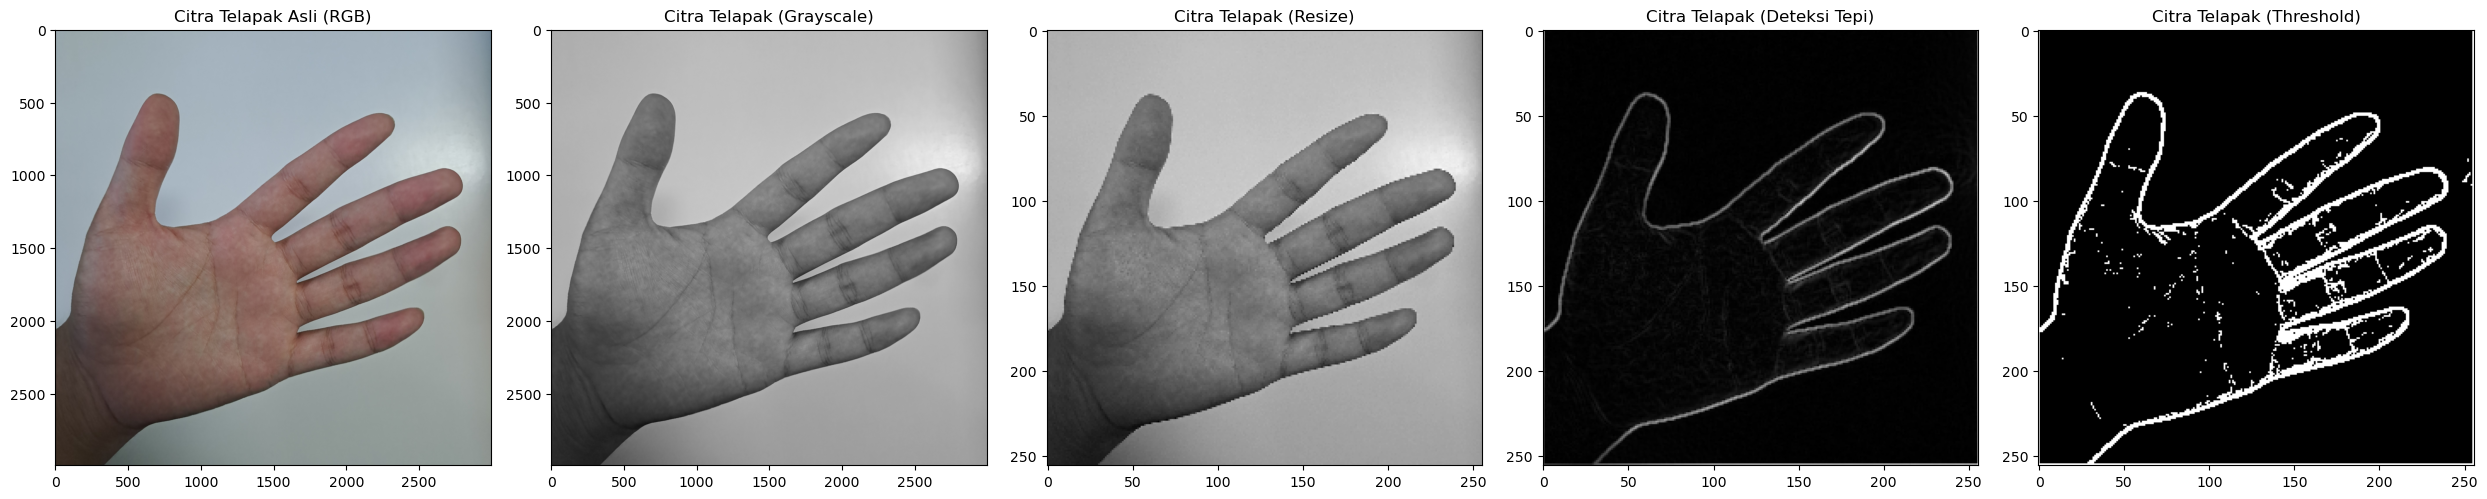

In [280]:
# KALAU MAU UBAH MIRIP DENGAN SOAL JURNAL, TINGGAL UBAH ASSET CITRA MENJADI "tangan"
telapak_asli = cv2.imread("../assets/telapak.jpeg")
telapak_rgb = cv2.cvtColor(telapak_asli, cv2.COLOR_BGR2RGB)
telapak_gray = cv2.cvtColor(telapak_rgb, cv2.COLOR_RGB2GRAY)
telapak_resize = resize(telapak_gray, 256, 256)
telapak_prewitt = deteksi_tepi(telapak_resize, kernel_prewitt_x, kernel_prewitt_y)
telapak_sobel = deteksi_tepi(telapak_resize, kernel_sobel_x, kernel_sobel_y)
telapak_tepi = kombinasi_tepi_normalisasi(telapak_prewitt, telapak_sobel)
telapak_threshold = threshold_manual(telapak_tepi, 20)

plt.figure(figsize=(25, 5))
plt.subplot(1, 5, 1)
plt.imshow(telapak_rgb)
plt.title("Citra Telapak Asli (RGB)")
plt.axis("on")

plt.subplot(1, 5, 2)
plt.imshow(telapak_gray, cmap="gray")
plt.title("Citra Telapak (Grayscale)")
plt.axis("on")

plt.subplot(1, 5, 3)
plt.imshow(telapak_resize, cmap="gray")
plt.title("Citra Telapak (Resize)")
plt.axis("on")

plt.subplot(1, 5, 4)
plt.imshow(telapak_tepi, cmap="gray")
plt.title("Citra Telapak (Deteksi Tepi)")
plt.axis("on")

plt.subplot(1, 5, 5)
plt.imshow(telapak_threshold, cmap="gray")
plt.title("Citra Telapak (Threshold)")
plt.axis("on")
plt.tight_layout()
plt.show()

## PROSES MORFOLOGI MATRIKS 3x3

### DILASI

*Cell code* di bawah ini mendefinisikan fungsi `dilasi(citra, kernel)` yang merupakan implementasi manual dari salah satu operasi fundamental dalam pengolahan citra morfologi untuk memperluas atau mempertebal hiasan geometris objek biner. Algoritma ini beroperasi dengan mengidentifikasi parameter dimensi spasial citra beserta struktur elemen (`kernel`), lalu menyiapkan sebuah matriks kosong `kanvas` bertipe data `np.uint8` sebagai media penampung hasil rekonstruksi bentuk. Melalui mekanisme kalang bersarang (*nested loops*), setiap koordinat piksel diperiksa secara berulang; apabila ditemukan piksel citra yang bernilai 255 (merepresentasikan objek utama), program akan mengaktifkan jendela operasi untuk menelusuri seluruh elemen bobot *kernel*. Secara teknis, jika elemen *kernel* pada koordinat indeks `[k_baris, k_kolom]` bernilai 1, fungsi ini akan menghitung posisi koordinat target spasial yang baru berdasarkan titik acuan `pusat_baris` dan `pusat_kolom` guna menjaga konsistensi pergeseran objek geometris. Setelah melalui tahap validasi batas (*boundary checking*) untuk memastikan koordinat `target_baris` dan `target_kolom` tetap berada di dalam ruang dimensi matriks citra, piksel pada matriks `kanvas` akan dipaksa bernilai 255, sehingga objek biner mengalami ekspansi struktural yang efektif untuk menutup lubang-lubang kecil (*fusing gaps*) serta menghubungkan kontur komponen yang terpisah pada tahapan analisis morfologi selanjutnya. Kemudian ditampilkan dengan `plt.subplot()`.

In [281]:
def dilasi(citra, kernel):
    tinggi = citra.shape[0]
    lebar = citra.shape[1]
    tinggi_kernel = kernel.shape[0]
    lebar_kernel = kernel.shape[1]
    kanvas = np.zeros((tinggi, lebar), dtype=np.uint8)
    pusat_baris = tinggi_kernel // 2
    pusat_kolom = lebar_kernel // 2
    for baris in range(tinggi):
        for kolom in range(lebar):
            if citra[baris, kolom] == 255:
                for k_baris in range(tinggi_kernel):
                    for k_kolom in range(lebar_kernel):
                        if kernel[k_baris, k_kolom] == 1:
                            target_baris = baris + k_baris - pusat_baris
                            target_kolom = kolom + k_kolom - pusat_kolom
                            if (
                                0 <= target_baris < tinggi
                                and 0 <= target_kolom < lebar
                            ):
                                kanvas[target_baris, target_kolom] = 255
    return kanvas

(256, 256)


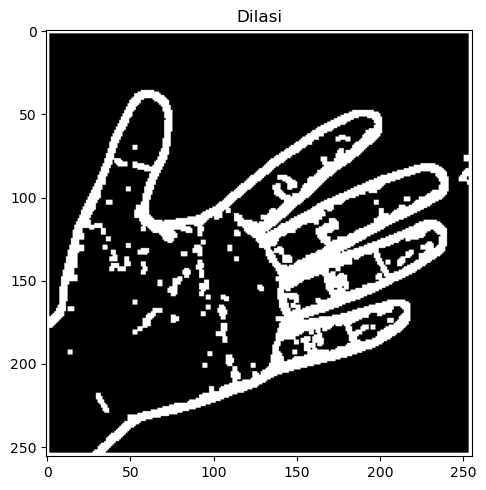

In [282]:
telapak_dilasi_3X3 = dilasi(telapak_threshold, kernel_fullsatu_3X3)

print(telapak_dilasi_3X3.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_dilasi_3X3, cmap="gray")
plt.title("Dilasi")
plt.axis("on")
plt.tight_layout()
plt.show()

### EROSI

*Cell code* berikut mendefinisikan dan menerapkan fungsi `erosi(citra, kernel)` yang berfungsi untuk melakukan operasi morfologi dasar erosi secara manual guna mengikis atau memperkecil dimensi struktural tepi dari objek biner. Secara teknis, fungsi ini menyiapkan sebuah matriks kosong `kanvas` berukuran sama dengan citra masukan dengan tipe data `np.uint8`, kemudian menggunakan titik koordinat pusat *kernel* sebagai acuan penyelarasan spasial jendela operasi. Melalui mekanisme kalang bersarang (*nested loops*), setiap piksel citra yang bernilai 255 diperiksa terhadap kecocokan penempatan elemen *kernel* yang bernilai 1; apabila terdapat satu saja elemen tetangga citra pada koordinat target yang bernilai 0 atau jika koordinat tersebut berada di luar batas dimensi gambar, maka variabel penanda `cocok` akan diubah menjadi nilai salah (*false*) sehingga piksel pusat tersebut dieliminasi menjadi 0 pada matriks hasil. Operasi ini kemudian diaplikasikan pada citra `telapak_threshold` menggunakan elemen penstruktur penuh `kernel_fullsatu_3X3` untuk menghasilkan citra `telapak_erosi_3X3` yang memiliki struktur kontur objek lebih ramping serta sangat efektif untuk menghilangkan komponen derau kecil yang terisolasi di sekitar objek telapak tangan, sebelum akhirnya divisualisasikan ke layar menggunakan peta warna skala abu-abu melalui fungsi `plt.imshow()` dengan sumbu koordinat yang tetap aktif sebagai indikator visual posisi spasial piksel.

In [283]:
def erosi(citra, kernel):
    tinggi = citra.shape[0]
    lebar = citra.shape[1]
    tinggi_kernel = kernel.shape[0]
    lebar_kernel = kernel.shape[1]
    kanvas = np.zeros((tinggi, lebar), dtype=np.uint8)
    pusat_baris = tinggi_kernel // 2
    pusat_kolom = lebar_kernel // 2
    for baris in range(tinggi):
        for kolom in range(lebar):
            if citra[baris, kolom] == 255:
                cocok = True
                for k_baris in range(tinggi_kernel):
                    for k_kolom in range(lebar_kernel):
                        if kernel[k_baris, k_kolom] == 1:
                            target_baris = baris + k_baris - pusat_baris
                            target_kolom = kolom + k_kolom - pusat_kolom
                            if 0 <= target_baris < tinggi and 0 <= target_kolom < lebar:
                                if citra[target_baris, target_kolom] == 0:
                                    cocok = False
                                    break
                            else:
                                cocok = False
                                break
                    if not cocok:
                        break
                if cocok:
                    kanvas[baris, kolom] = 255
    return kanvas

(256, 256)


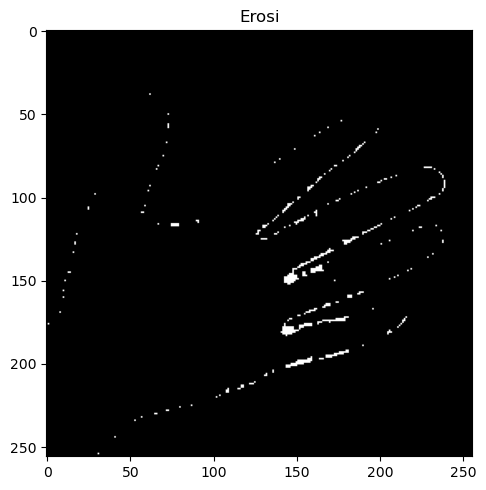

In [284]:
telapak_erosi_3X3 = erosi(telapak_threshold, kernel_fullsatu_3X3)

print(telapak_erosi_3X3.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_erosi_3X3, cmap="gray")
plt.title("Erosi")
plt.axis("on")
plt.tight_layout()
plt.show()

### OPENING

*Cell code* di bawah mendefinisikan dan menerapkan fungsi `opening(citra, kernel)` yang berfungsi untuk mengeksekusi operasi morfologi lanjutan *opening* secara sekuensial guna membersihkan komponen derau pada citra biner. Secara teknis, fungsi ini memanfaatkan sifat komposit dari dua operasi dasar yang telah diimplementasikan sebelumnya, di mana citra masukan terlebih dahulu dikikis menggunakan fungsi `erosi()` untuk mengeliminasi objek-objek kecil atau detail tepi yang tidak berpasangan dengan struktur *kernel*, lalu hasil pengikisan tersebut langsung diperluas kembali dimensinya menggunakan fungsi `dilasi()`. Operasi ini diterapkan pada variabel `telapak_threshold` menggunakan elemen penstruktur penuh `kernel_fullsatu_3X3` untuk menghasilkan citra baru `telapak_opening_3X3` yang secara geometris sangat efektif untuk menghilangkan derau bintik putih (*salt noise*) yang terisolasi di area latar belakang tanpa mengubah ukuran serta bentuk struktural utama dari objek telapak tangan secara masif. Hasil transformasi spasial ini kemudian diperiksa dimensi matriksnya melalui instruksi `.shape` dan ditampilkan ke dalam satu bidang gambar memanfaatkan fungsi `plt.imshow()` dengan peta warna *grayscale* serta sumbu koordinat yang diaktifkan (`plt.axis("on")`) untuk mempermudah pemantauan perubahan posisi piksel pasca-proses filtrasi morfologi.

In [285]:
def opening(citra, kernel):
    return dilasi(erosi(citra, kernel), kernel)

(256, 256)


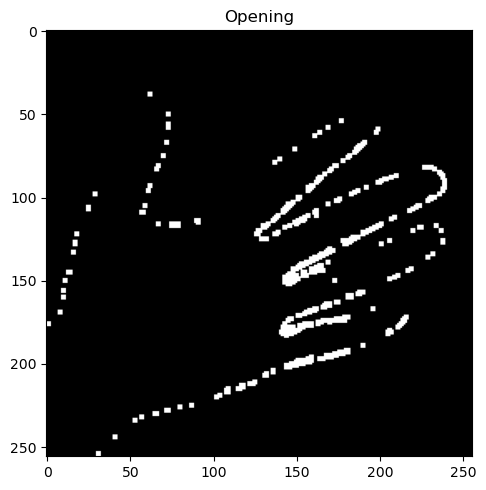

In [286]:
telapak_opening_3X3 = opening(telapak_threshold, kernel_fullsatu_3X3)

print(telapak_opening_3X3.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_opening_3X3, cmap="gray")
plt.title("Opening")
plt.axis("on")
plt.tight_layout()
plt.show()

### CLOSING

*Cell code* di bawah mendefinisikan dan menerapkan fungsi `closing(citra, kernel)` yang berfungsi untuk mengeksekusi operasi morfologi lanjutan *closing* secara sekuensial guna menjembatani celah dan menutup lubang kecil pada objek citra biner. Secara teknis, fungsi ini bekerja dengan memanfaatkan urutan komposit yang berkebalikan dari operasi *opening*, di mana citra masukan `telapak_threshold` terlebih dahulu diperluas strukturnya menggunakan fungsi `dilasi()` untuk menyatukan komponen kontur yang terpisah atau mengisi kekosongan intensitas di dalam objek, lalu hasil ekspansi tersebut langsung dikikis kembali ukurannya secara proporsional menggunakan fungsi `erosi()`. Implementasi operasi ini menggunakan elemen penstruktur penuh `kernel_fullsatu_3X3` menghasilkan citra baru `telapak_closing_3X3` yang secara geometris sangat efektif untuk mengeliminasi derau berupa lubang hitam kecil (*pepper noise*) di dalam struktur utama telapak tangan serta menghaluskan lekukan kontur tepi yang terputus tanpa memicu pembengkakan dimensi objek secara permanen. Matriks hasil fusi morfologi ini kemudian diperiksa konsistensi ukurannya melalui instruksi `.shape` dan divisualisasikan ke layar menggunakan fungsi `plt.imshow()` dengan peta warna skala abu-abu serta sumbu koordinat yang tetap diaktifkan (`plt.axis("on")`) sebagai indikator validitas spasial piksel pasca-pemrosesan.

In [287]:
def closing(citra, kernel):
    return erosi(dilasi(citra, kernel), kernel)

(256, 256)


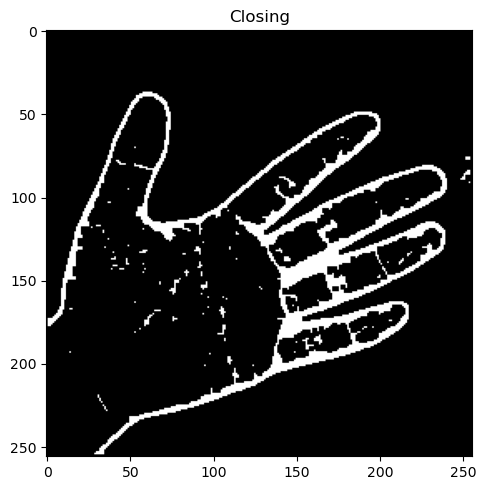

In [288]:
telapak_closing_3X3 = closing(telapak_threshold, kernel_fullsatu_3X3)

print(telapak_closing_3X3.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_closing_3X3, cmap="gray")
plt.title("Closing")
plt.axis("on")
plt.tight_layout()
plt.show()

### THINNING

Pada *cell code* di bawah mendefinisikan dan menerapkan fungsi `thinning(citra)` yang mengimplementasikan secara manual algoritma *thinning* (penipisan) pada citra biner. Secara teknis, algoritma ini diawali dengan menginisialisasi matriks `kanvas_kerja` berukuran `(tinggi + 2, lebar + 2)` bertipe `np.uint8` untuk menerapkan teknik *padding* otomatis, yang memetakan piksel objek bernilai intensitas lebih dari 0 menjadi nilai logika 1. Pemrosesan dilakukan di dalam kalang `while` interaktif yang akan terus mengeksekusi iterasi sub-tahap selama variabel penanda `ada_perubahan` bernilai benar (*true*). Pada setiap iterasi, algoritma memeriksa ketetanggaan 8-piksel ($p_2$ hingga $p_9$) searah jarum jam untuk menghitung jumlah tetangga aktif serta total transisi pola konektivitas dari nilai 0 ke 1. Guna menjaga topologi struktur asli objek telapak tangan agar tidak terputus, piksel target dimasukkan ke dalam `matriks_hapus` jika memenuhi empat syarat kondisional ketat, termasuk batasan jumlah tetangga aktif di antara nilai 2 hingga 6, nilai transisi tepat sama dengan 1, serta eliminasi piksel ujung berdasarkan kombinasi produk logis tetangga ortogonal yang membedakan sub-iterasi pertama dan kedua. Setelah objek dikikis lapis demi lapis hingga mencapai kondisi konvergen di mana tidak ada lagi piksel tepi yang dapat dieliminasi, matriks dipetakan kembali ke dimensi asalnya pada variabel `hasil_akhir` dengan mengembalikan nilai intensitas puncak 255. Hasil akhir berupa citra `telapak_thinning_3X3` kemudian divisualisasikan menggunakan fungsi `plt.imshow()` dengan peta warna *grayscale* dan sumbu koordinat yang tetap aktif untuk mempermudah pengamatan reduksi geometris komponen garis guratan tangan menjadi setebal satu piksel secara presisi.

In [289]:
def thinning(citra):
    tinggi = citra.shape[0]
    lebar = citra.shape[1]
    kanvas_kerja = np.zeros((tinggi + 2, lebar + 2), dtype=np.uint8)
    for baris in range(tinggi):
        for kolom in range(lebar):
            if citra[baris, kolom] > 0:
                kanvas_kerja[baris + 1, kolom + 1] = 1
    ada_perubahan = True
    while ada_perubahan:
        ada_perubahan = False
        matriks_hapus = np.zeros((tinggi + 2, lebar + 2), dtype=np.uint8)
        for baris in range(1, tinggi + 1):
            for kolom in range(1, lebar + 1):
                if kanvas_kerja[baris, kolom] == 1:
                    p2 = kanvas_kerja[baris - 1, kolom]
                    p3 = kanvas_kerja[baris - 1, kolom + 1]
                    p4 = kanvas_kerja[baris, kolom + 1]
                    p5 = kanvas_kerja[baris + 1, kolom + 1]
                    p6 = kanvas_kerja[baris + 1, kolom]
                    p7 = kanvas_kerja[baris + 1, kolom - 1]
                    p8 = kanvas_kerja[baris, kolom - 1]
                    p9 = kanvas_kerja[baris - 1, kolom - 1]
                    jumlah_tetangga = p2 + p3 + p4 + p5 + p6 + p7 + p8 + p9
                    transisi = 0
                    if p2 == 0 and p3 == 1: transisi += 1
                    if p3 == 0 and p4 == 1: transisi += 1
                    if p4 == 0 and p5 == 1: transisi += 1
                    if p5 == 0 and p6 == 1: transisi += 1
                    if p6 == 0 and p7 == 1: transisi += 1
                    if p7 == 0 and p8 == 1: transisi += 1
                    if p8 == 0 and p9 == 1: transisi += 1
                    if p9 == 0 and p2 == 1: transisi += 1
                    if (
                        (2 <= jumlah_tetangga <= 6)
                        and (transisi == 1)
                        and (p2 * p4 * p6 == 0)
                        and (p4 * p6 * p8 == 0)
                    ):
                        matriks_hapus[baris, kolom] = 1
                        ada_perubahan = True
        for baris in range(1, tinggi + 1):
            for kolom in range(1, lebar + 1):
                if matriks_hapus[baris, kolom] == 1:
                    kanvas_kerja[baris, kolom] = 0
        matriks_hapus = np.zeros((tinggi + 2, lebar + 2), dtype=np.uint8)
        for baris in range(1, tinggi + 1):
            for kolom in range(1, lebar + 1):
                if kanvas_kerja[baris, kolom] == 1:
                    p2 = kanvas_kerja[baris - 1, kolom]
                    p3 = kanvas_kerja[baris - 1, kolom + 1]
                    p4 = kanvas_kerja[baris, kolom + 1]
                    p5 = kanvas_kerja[baris + 1, kolom + 1]
                    p6 = kanvas_kerja[baris + 1, kolom]
                    p7 = kanvas_kerja[baris + 1, kolom - 1]
                    p8 = kanvas_kerja[baris, kolom - 1]
                    p9 = kanvas_kerja[baris - 1, kolom - 1]
                    jumlah_tetangga = p2 + p3 + p4 + p5 + p6 + p7 + p8 + p9
                    transisi = 0
                    if p2 == 0 and p3 == 1: transisi += 1
                    if p3 == 0 and p4 == 1: transisi += 1
                    if p4 == 0 and p5 == 1: transisi += 1
                    if p5 == 0 and p6 == 1: transisi += 1
                    if p6 == 0 and p7 == 1: transisi += 1
                    if p7 == 0 and p8 == 1: transisi += 1
                    if p8 == 0 and p9 == 1: transisi += 1
                    if p9 == 0 and p2 == 1: transisi += 1
                    if (
                        (2 <= jumlah_tetangga <= 6)
                        and (transisi == 1)
                        and (p2 * p4 * p8 == 0)
                        and (p2 * p6 * p8 == 0)
                    ):
                        matriks_hapus[baris, kolom] = 1
                        ada_perubahan = True
        for baris in range(1, tinggi + 1):
            for kolom in range(1, lebar + 1):
                if matriks_hapus[baris, kolom] == 1:
                    kanvas_kerja[baris, kolom] = 0
    hasil_akhir = np.zeros((tinggi, lebar), dtype=np.uint8)
    for baris in range(tinggi):
        for kolom in range(lebar):
            if kanvas_kerja[baris + 1, kolom + 1] == 1:
                hasil_akhir[baris, kolom] = 255
    return hasil_akhir

(256, 256)


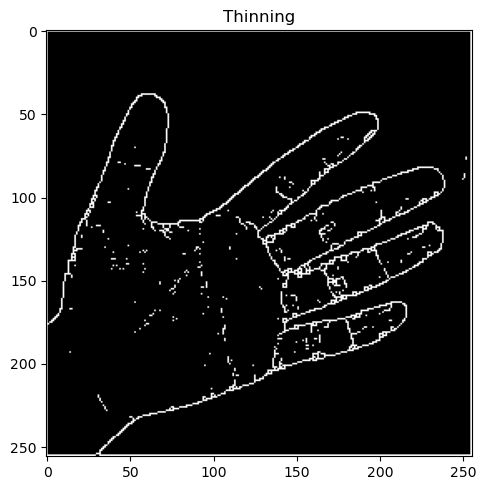

In [290]:
telapak_thinning_3X3 = thinning(telapak_threshold)

print(telapak_thinning_3X3.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_thinning_3X3, cmap="gray")
plt.title("Thinning")
plt.axis("on")
plt.tight_layout()
plt.show()

### THICKENING

*Cell code* di atas mendefinisikan dan menerapkan fungsi `thickening(citra, kernel, iterasi=1)` yang berfungsi untuk melakukan penebalan geometris struktur objek pada citra biner secara bertahap. Secara teknis, fungsi ini diawali dengan menduplikasi seluruh data piksel dari matriks `citra` masukan ke dalam variabel `hasil` menggunakan alokasi memori berukuran sama bertipe data `np.uint8` melalui mekanisme kalang bersarang (*nested loops*). Proses penebalan bentuk kemudian dieksekusi di dalam kalang `for putaran in range(iterasi)` yang memanfaatkan sifat komposit dari fungsi `dilasi()` secara berulang sebanyak parameter `iterasi` yang ditentukan, sehingga setiap siklus akan mengekspansi area batas luar kontur objek biner secara sekuensial. Operasi ini diaplikasikan pada citra `telapak_threshold` menggunakan elemen penstruktur penuh `kernel_fullsatu_3X3` untuk menghasilkan citra `telapak_thickening_3X3` yang secara visual memperluas ukuran guratan garis dan bentuk telapak tangan guna memperkuat keterhubungan antarkomponen spasial piksel yang renggang. Hasil akhir dari proses fusi morfologi ini kemudian diperiksa dimensi matriksnya melalui instruksi `.shape` dan ditampilkan ke layar memanfaatkan fungsi `plt.imshow()` dengan peta warna *grayscale* serta sumbu koordinat yang tetap aktif (`plt.axis("on")`) untuk mendeteksi tingkat pertumbuhan ketebalan piksel objek pasca-proses transformasi.

In [291]:
def thickening(citra, kernel, iterasi=1):
    tinggi = citra.shape[0]
    lebar = citra.shape[1]
    hasil = np.zeros((tinggi, lebar), dtype=np.uint8)
    for baris in range(tinggi):
        for kolom in range(lebar):
            hasil[baris, kolom] = citra[baris, kolom]
    for putaran in range(iterasi):
        hasil = dilasi(hasil, kernel)
    return hasil

(256, 256)


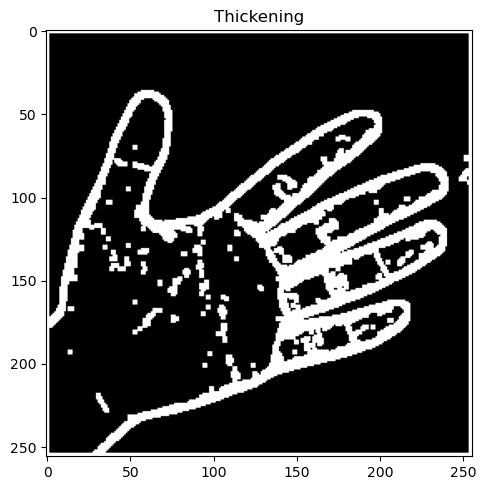

In [292]:
telapak_thickening_3X3 = thickening(telapak_threshold, kernel_fullsatu_3X3)

print(telapak_thickening_3X3.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_thickening_3X3, cmap="gray")
plt.title("Thickening")
plt.axis("on")
plt.tight_layout()
plt.show()

### GRADIENT MORPH

Pada *cell code* di bawah mendefinisikan dan menerapkan fungsi `gradient_morph(citra, kernel)` yang berfungsi untuk mengeksekusi operasi *morphological gradient* secara manual guna mengekstraksi fitur batas kontur tepi suatu objek biner. Secara teknis, fungsi ini bekerja dengan memanfaatkan selisih spasial dari dua operasi morfologi dasar yang telah diimplementasikan sebelumnya, di mana citra masukan terlebih dahulu diperluas batas luarnya menggunakan fungsi `dilasi()` menghasilkan `citra_tebal`, serta dikikis batas dalamnya menggunakan fungsi `erosi()` menghasilkan `citra_tipis`. Melalui mekanisme kalang bersarang (*nested loops*), setiap koordinat piksel diekstraksi nilainya ke dalam tipe data *integer* untuk dihitung nilai selisih absolut intensitasnya secara *pixel-wise*. Guna mengantisipasi terjadinya galat nilai di luar rentang biner akibat operasi pengurangan matriks, fungsi ini menerapkan logika pembatasan (*clipping*) ketat di mana hasil selisih yang berada di bawah nilai 0 dipaksa menjadi 0, dan yang melampaui nilai 255 dipotong menjadi 255 sebelum disimpan ke dalam matriks `hasil` bertipe data `np.uint8`. Operasi ini diaplikasikan pada variabel `telapak_threshold` menggunakan elemen penstruktur penuh `kernel_fullsatu_3X3` untuk menghasilkan citra baru `telapak_gradient_morph_3X3` yang secara geometris sangat efektif untuk mengisolasi struktur garis tepi terluar (*outline*) dan guratan internal dari objek telapak tangan dengan ketebalan yang seragam. Hasil akhir dari proses fusi kontur ini kemudian diperiksa dimensi matriksnya melalui instruksi `.shape` dan ditampilkan ke layar memanfaatkan fungsi `plt.imshow()` dengan peta warna *grayscale* serta sumbu koordinat yang diaktifkan (`plt.axis("on")`) untuk memvalidasi presisi spasial piksel hasil ekstraksi tepi morfologi tersebut.

In [293]:
def gradient_morph(citra, kernel):
    citra_tebal = dilasi(citra, kernel)
    citra_tipis = erosi(citra, kernel)
    tinggi = citra.shape[0]
    lebar = citra.shape[1]
    hasil = np.zeros((tinggi, lebar), dtype=np.uint8)
    for baris in range(tinggi):
        for kolom in range(lebar):
            nilai_tebal = int(citra_tebal[baris, kolom])
            nilai_tipis = int(citra_tipis[baris, kolom])
            selisih = nilai_tebal - nilai_tipis
            if selisih < 0:
                selisih = 0
            elif selisih > 255:
                selisih = 255
            hasil[baris, kolom] = selisih
    return hasil

(256, 256)


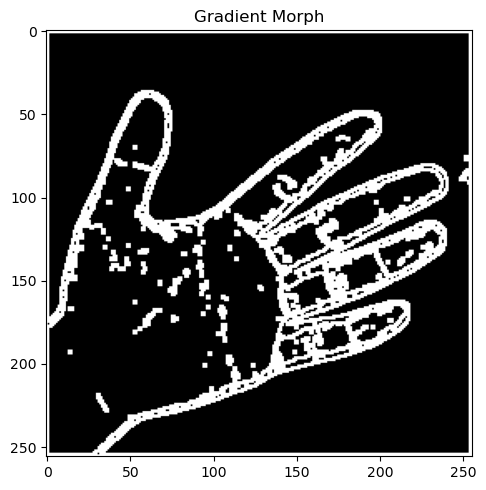

In [294]:
telapak_gradient_morph_3X3 = gradient_morph(telapak_threshold, kernel_fullsatu_3X3)

print(telapak_gradient_morph_3X3.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_gradient_morph_3X3, cmap="gray")
plt.title("Gradient Morph")
plt.axis("on")
plt.tight_layout()
plt.show()

### MENAMPILKAN SEMUA PROSES MORFOLOGI MATRIKS 3x3

*Cell code* ini berfungsi untuk menampilkan matriks perbandingan visual dari tujuh hasil operasi morfologi yang telah dieksekusi sebelumnya pada objek biner telapak tangan secara simultan dalam satu jendela gambar. Menggunakan fungsi `plt.figure(figsize=(16, 10))`, program mengalokasikan ruang kanvas berskala besar untuk menyusun tata letak *grid* matriks berukuran 2x4 memanfaatkan rangkaian instruksi `plt.subplot()`. Pada baris pertama *grid*, ditampilkan empat operasi morfologi mendasar: `telapak_dilasi_3X3` yang memperluas dimensi objek, `telapak_erosi_3X3` yang mengikis tepian kontur, `telapak_opening_3X3` yang membersihkan derau luar (*salt noise*), dan `telapak_closing_3X3` yang menutup lubang internal (*pepper noise*). Memasuki baris kedua *grid*, visualisasi dilanjutkan untuk menampilkan operasi tingkat lanjut: `telapak_thinning_3X3` yang mereduksi geometri komponen menjadi rangka setebal satu piksel (*skeleton*), `telapak_thickening_3X3` yang menebalkan struktur secara sekuensial, dan `telapak_gradient_morph_3X3` yang mengisolasi garis batas kontur terluar (*outline*). Setiap sub-gambar dipetakan menggunakan peta warna skala abu-abu melalui parameter `cmap="gray"` dan dilengkapi judul representatif via `plt.title()`, sementara sumbu koordinat dinonaktifkan menggunakan `plt.axis("off")` agar fokus pengamatan tertuju sepenuhnya pada perubahan geometris objek. Seluruh struktur tata letak ini diakhiri dengan instruksi `plt.tight_layout()` dan `plt.show()` untuk memastikan distribusi spasial antar-gambar tersusun secara rapi dan proporsional tanpa adanya tumpang tindih teks.

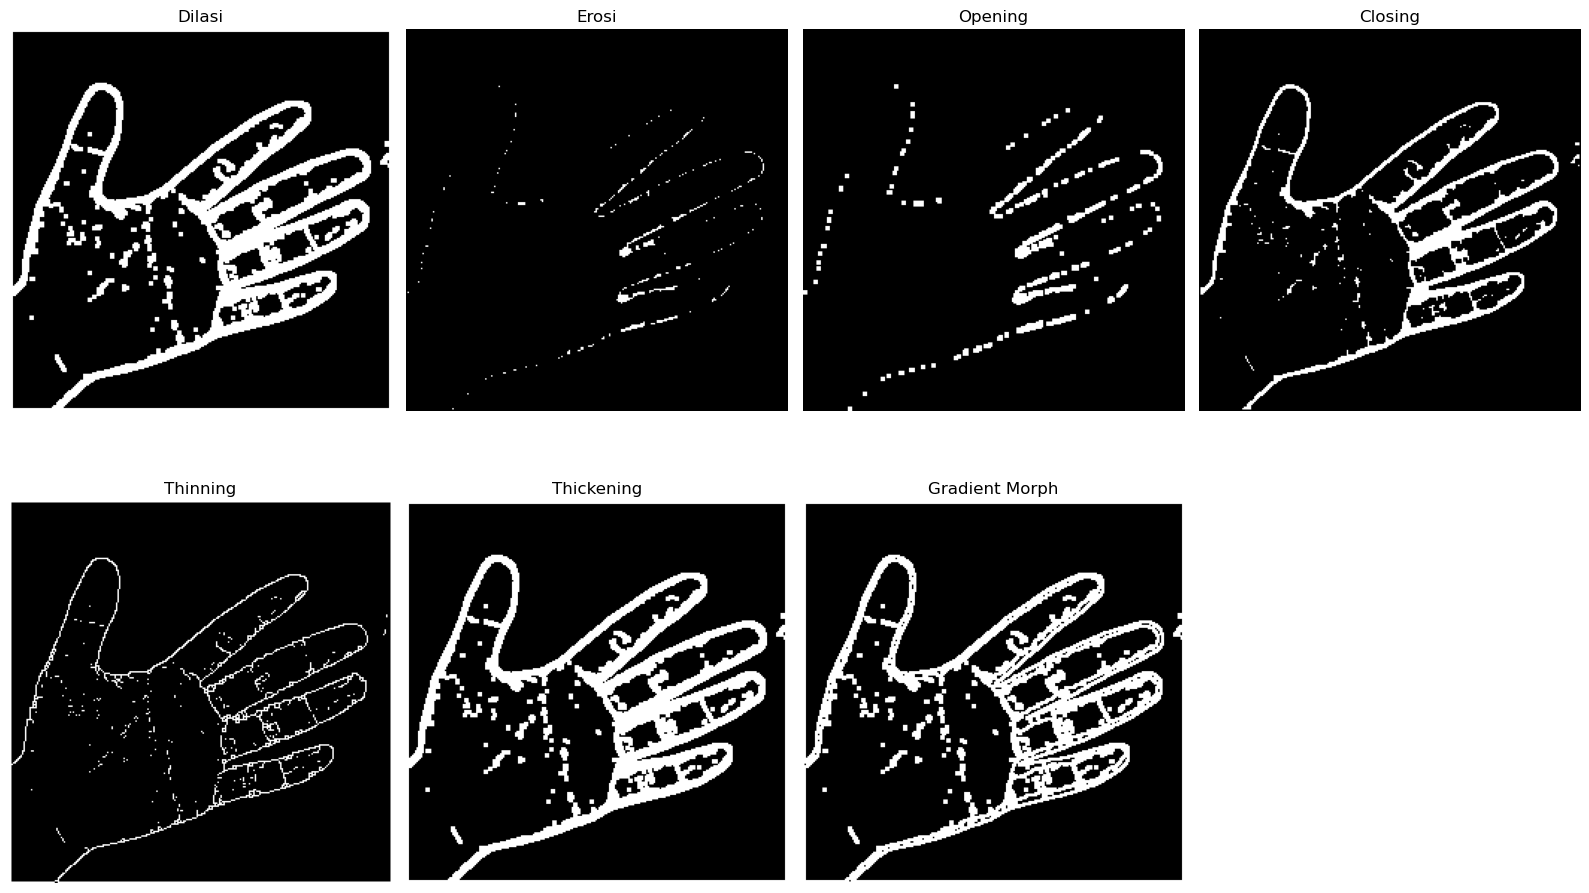

In [295]:
plt.figure(figsize=(16, 10))
plt.subplot(2, 4, 1)
plt.imshow(telapak_dilasi_3X3, cmap="gray")
plt.title("Dilasi")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(telapak_erosi_3X3, cmap="gray")
plt.title("Erosi")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(telapak_opening_3X3, cmap="gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(telapak_closing_3X3, cmap="gray")
plt.title("Closing")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(telapak_thinning_3X3, cmap="gray")
plt.title("Thinning")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(telapak_thickening_3X3, cmap="gray")
plt.title("Thickening")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(telapak_gradient_morph_3X3, cmap="gray")
plt.title("Gradient Morph")
plt.axis("off")
plt.tight_layout()
plt.show()

### ANALISIS MORFOLOGI 3x3

Berdasarkan hasil eksekusi pengolahan citra menggunakan kernel $3\times3$, kita dapat mengamati berbagai perubahan signifikan pada citra kontur telapak tangan dibandingkan dengan citra *threshold* aslinya. Operasi **dilasi** membuat garis kontur tepi telapak tangan menjadi jauh lebih tebal dan tegas, serta menutup celah-celah sempit yang kosong di antara piksel putih yang berdekatan. Sebaliknya, operasi **erosi** mengikis lapisan terluar objek sehingga garis kontur menjadi lebih tipis, menghilangkan titik-titik *noise* di sekitarnya, dan bahkan memutus garis-garis batas yang sejak awal sudah terlalu tipis. Pada operasi **opening** (kombinasi erosi yang dilanjutkan dengan dilasi), citra terlihat lebih bersih dari bercak *noise* kecil di luar kontur utama, dengan ketebalan garis yang relatif kembali seperti semula, meskipun beberapa detail halus yang terhapus saat fase erosi tidak dapat dikembalikan seutuhnya. Sementara itu, operasi **closing** (dilasi yang dilanjutkan dengan erosi) sangat efektif untuk menutup lubang kecil atau menyambungkan celah sempit yang terputus di dalam garis tepi kontur, menjadikannya lebih solid dan utuh tanpa mengubah ketebalan aslinya secara drastis. Selanjutnya, proses **thinning** mereduksi objek secara signifikan hingga mencapai kerangka dasarnya saja, menghasilkan garis-garis tipis kerangka yang merepresentasikan struktur utama dari kontur telapak tangan asli. Operasi **thickening** memberikan hasil visual yang sangat mirip dengan dilasi, yakni mempertebal dan menambahkan lapisan pada area putih kontur. Terakhir, **gradient morph** (selisih antara hasil dilasi dan erosi) menciptakan efek visual berupa tepi yang lebih terfokus, di mana batas luar dan dalam dari garis tebal orisinalnya diekstraksi, meninggalkan jejak tepian yang menonjolkan kontur batas aslinya.

## PROSES MORFOLOGI MATRIKS 5x5

### DILASI

*Cell code* berikut ini berfungsi untuk mengeksekusi operasi morfologi dasar dilasi pada citra biner telapak tangan menggunakan ukuran elemen penstruktur yang lebih besar. Pada tahapan ini, fungsi `dilasi()` yang telah didefinisikan sebelumnya dipanggil kembali dengan melewatkan variabel `telapak_threshold` sebagai citra sumber dan `kernel_fullsatu_5X5` sebagai matriks operatornya. Secara teknis, penggunaan elemen penstruktur penuh berdimensi 5x5 piksel ini memberikan efek ekspansi geometris yang jauh lebih agresif dibandingkan dengan *kernel* berukuran 3x3. Jendela operasi yang bergeser secara spasial di atas matriks akan memaksa seluruh piksel tetangga dalam jangkauan $5 \times 5$ menjadi nilai intensitas puncak 255 ketika piksel pusat mendeteksi bagian dari objek, sehingga menghasilkan citra baru `telapak_dilasi_5X5` dengan karakteristik kontur objek yang jauh lebih tebal, celah-celah kosong yang tertutup secara masif, dan penggabungan komponen guratan tangan yang terpisah secara signifikan. Hasil transformasi spasial ini kemudian diperiksa akurasi dimensinya melalui instruksi `.shape` dan divisualisasikan ke layar menggunakan fungsi `plt.imshow()` dengan peta warna *grayscale* serta sumbu koordinat yang tetap diaktifkan (`plt.axis("on")`) untuk memberikan referensi visual yang jelas mengenai tingkat perluasan skala piksel objek pasca-proses rekonstruksi morfologi tersebut.

(256, 256)


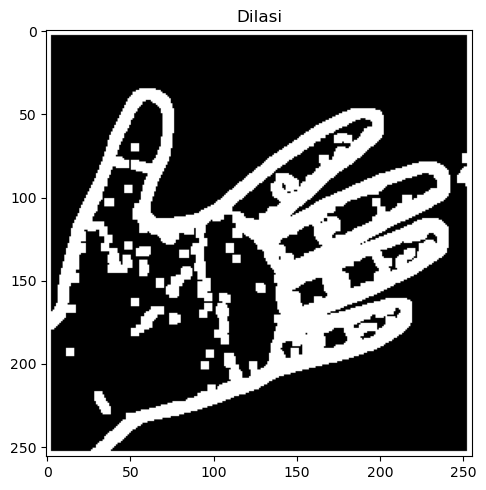

In [296]:
telapak_dilasi_5X5 = dilasi(telapak_threshold, kernel_fullsatu_5X5)

print(telapak_dilasi_5X5.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_dilasi_5X5, cmap="gray")
plt.title("Dilasi")
plt.axis("on")
plt.tight_layout()
plt.show()

### EROSI

Instruksi pemrograman berikut mengeksekusi proses pengikisan geometris pada matriks biner telapak tangan menggunakan elemen penstruktur berdimensi lebih luas. Di dalam tahapan ini, fungsi `erosi()` yang telah dibangun sebelumnya dipanggil kembali dengan melewatkan variabel `telapak_threshold` sebagai data masukan dan `kernel_fullsatu_5X5` sebagai matriks operator pengikisnya. Secara teknis, penerapan elemen penstruktur penuh berukuran $5 \times 5$ piksel ini memberikan efek penyusutan kontur yang jauh lebih agresif dibandingkan dengan pengujian menggunakan *kernel* berdimensi 3x3. Jendela operasi yang bergeser secara spasial menuntut tingkat kecocokan tetangga (*neighbourhood fit*) yang lebih ketat; apabila terdapat satu saja piksel berintensitas 0 dalam jangkauan area $5 \times 5$ di sekitar objek, maka piksel pusat pada matriks akan langsung dieliminasi menjadi 0. Mekanisme tersebut menghasilkan citra baru `telapak_erosi_5X5` yang memiliki karakteristik kontur objek jauh lebih ramping, serta secara masif mengikis detail guratan-guratan halus dan memotong komponen tepi yang tipis pada telapak tangan. Hasil transformasi spasial ini selanjutnya diperiksa konsistensi ukurannya via perintah `.shape` dan dipetakan ke layar menggunakan fungsi `plt.imshow()` dengan peta warna *grayscale*, di mana sumbu koordinat tetap dipertahankan aktif (`plt.axis("on")`) guna memberikan indikator visual yang presisi mengenai tingkat reduksi piksel objek pasca-proses filtrasi morfologi tersebut.

(256, 256)


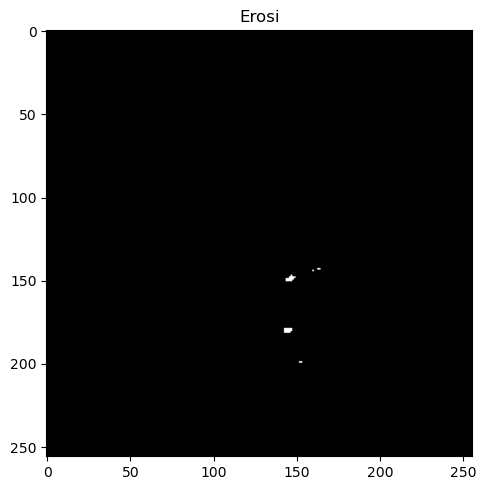

In [297]:
telapak_erosi_5X5 = erosi(telapak_threshold, kernel_fullsatu_5X5)

print(telapak_erosi_5X5.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_erosi_5X5, cmap="gray")
plt.title("Erosi")
plt.axis("on")
plt.tight_layout()
plt.show()

### OPENING

Sintaks program tersebut menerapkan teknik filtrasi morfologi tingkat lanjut *opening* pada matriks biner telapak tangan menggunakan elemen penstruktur berskala besar. Melalui pemanggilan fungsi `opening()`, citra input `telapak_threshold` diproses secara sekuensial dengan melewatkan operator `kernel_fullsatu_5X5`. Secara teknis, kombinasi urutan operasi yang diawali dengan pengikisan (`erosi`) dan dilanjutkan dengan pemekaran (`dilasi`) menggunakan *kernel* $5 \times 5$ piksel ini memberikan efek pembersihan derau yang sangat radikal. Dikarenakan ukuran elemen penstruktur yang masif, fase erosi pertama akan mengeliminasi seluruh objek biner yang tidak mampu memuat *kernel* berdimensi $5 \times 5$ di dalamnya, termasuk sebagian besar struktur utama kontur telapak tangan dan guratan-guratan jari yang ramping. Efek rekonstruksi pada fase dilasi berikutnya hanya mampu mengembalikan ukuran dari komponen objek sisa yang berhasil bertahan, sehingga memicu transformasi visual yang ekstrem di mana objek telapak tangan hilang dan hanya menyisakan beberapa klaster piksel putih terisolasi berukuran kecil pada bidang gambar `telapak_opening_5X5`. Hasil akhir dari fusi spasial tersebut kemudian diperiksa dimensi matriksnya melalui instruksi `.shape` dan dipetakan ke layar menggunakan fungsi `plt.imshow()` dengan peta warna *grayscale*, di mana sumbu koordinat tetap diaktifkan (`plt.axis("on")`) sebagai indikator visual yang menegaskan lenyapnya struktur geometri objek pasca-proses filtrasi agresif ini.

(256, 256)


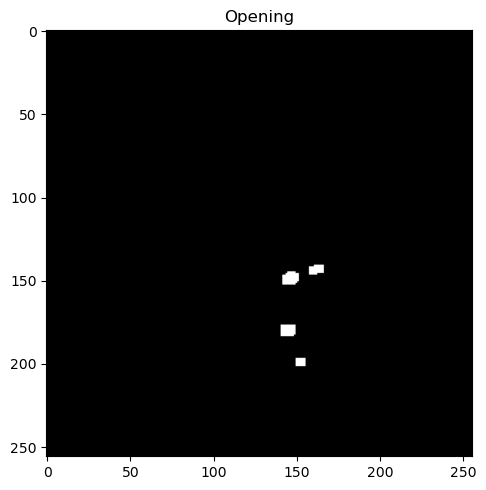

In [298]:
telapak_opening_5X5 = opening(telapak_threshold, kernel_fullsatu_5X5)

print(telapak_opening_5X5.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_opening_5X5, cmap="gray")
plt.title("Opening")
plt.axis("on")
plt.tight_layout()
plt.show()

### CLOSING

*Cell code* di bawah ini mengeksekusi operasi morfologi lanjutan *closing* pada citra biner telapak tangan menggunakan elemen penstruktur dengan skala dimensi yang maksimal. Melalui baris instruksi tersebut, fungsi `closing()` dipanggil secara sekuensial dengan melewatkan objek `telapak_threshold` beserta operator `kernel_fullsatu_5X5` sebagai parameter utamanya. Secara mekanis, pergeseran jendela operasi berdimensi $5 \times 5$ piksel ini menerapkan urutan komposit yang diawali dengan pemekaran kontur (`dilasi`) dan ditutup dengan pengikisan objek (`erosi`). Dikarenakan ukuran *kernel* penuh yang digunakan sangat masif, fase dilasi pertama akan memperluas setiap komponen putih secara agresif sejauh radius filter, yang secara instan menyatukan guratan-guratan internal yang berdekatan serta menutup celah-celah kosong di dalam maupun di sekitar objek telapak tangan secara masif. Ketika fase erosi kedua berjalan untuk mengembalikan proporsi dimensi luar objek, rongga-rongga internal yang sudah terlanjur menyatu terperangkap dan permanen menjadi padat, sehingga menghasilkan visualisasi `telapak_closing_5X5` dengan area biner putih yang tampak lebih solid dan menyatu dibandingkan hasil pengujian filter berukuran kecil. Struktur matriks keluaran ini kemudian dipastikan dimensinya lewat perintah `.shape` dan ditampilkan ke layar via fungsi `plt.imshow()` menggunakan peta warna skala abu-abu, dengan sumbu koordinat tetap dibiarkan aktif (`plt.axis("on")`) sebagai acuan spasial perubahan kerapatan piksel objek.

(256, 256)


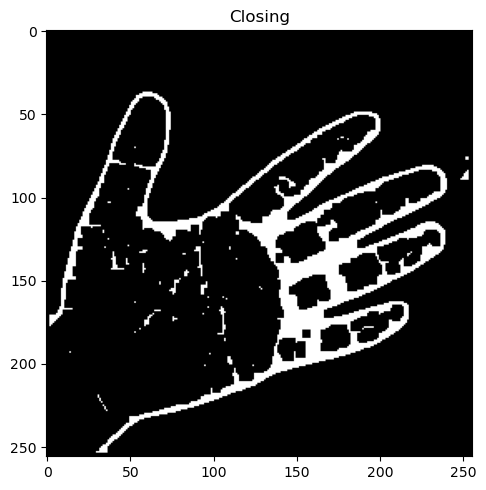

In [299]:
telapak_closing_5X5 = closing(telapak_threshold, kernel_fullsatu_5X5)

print(telapak_closing_5X5.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_closing_5X5, cmap="gray")
plt.title("Closing")
plt.axis("on")
plt.tight_layout()
plt.show()

### THINNING

*Cell code* berikut ini menerapkan algoritma penipisan (*thinning*) secara manual pada variabel `telapak_threshold` untuk mengekstraksi struktur rangka dasar (*skeleton*) dari objek telapak tangan. Berbeda dengan operasi morfologi sebelumnya yang bergantung pada dimensi elemen penstruktur ganjil, fungsi `thinning()` yang dieksekusi pada baris kode ini bekerja secara independen langsung terhadap struktur geometri internal citra biner itu sendiri melalui analisis ketetanggaan 8-piksel yang iteratif. Secara teknis, proses reduksi spasial ini memakan waktu komputasi yang bervariasi bergantung pada ketebalan awal objek, di mana setiap iterasi sub-tahap akan mengikis piksel-piksel tepi terluar secara merata hingga menyisakan kontur garis tunggal setebal satu piksel saja. Karena citra masukan yang dilewatkan merupakan matriks hasil ambang batas standar, implementasi penipisan ini menghasilkan visualisasi rangka `telapak_thinning_5X5` yang merepresentasikan jalur topologi murni dari guratan tangan serta siluet jari-jari tanpa memutus kontinuitas komponen objek biner. Hasil transformasi linear tersebut kemudian dipastikan ukuran dimensinya melalui pemanggilan instruksi `.shape` dan dipetakan ke layar menggunakan fungsi `plt.imshow()` dengan peta warna skala abu-abu, lengkap dengan sumbu koordinat yang dipertahankan aktif (`plt.axis("on")`) sebagai indikator akurasi posisi geometris piksel pasca-proses penipisan kontur.

(256, 256)


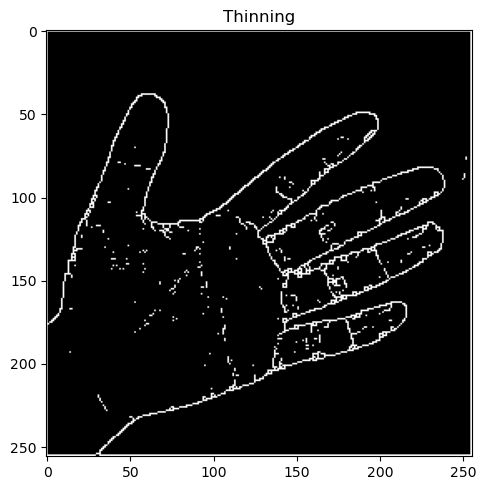

In [300]:
telapak_thinning_5X5 = thinning(telapak_threshold)

print(telapak_thinning_5X5.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_thinning_5X5, cmap="gray")
plt.title("Thinning")
plt.axis("on")
plt.tight_layout()
plt.show()

### THICKENING

*Cell code* berikut ini mengeksekusi fungsi penebalan morfologi (*thickening*) secara sekuensial pada citra biner telapak tangan menggunakan elemen penstruktur dengan skala dimensi yang lebih luas. Melalui baris perintah tersebut, fungsi `thickening()` dijalankan dengan melewatkan parameter citra `telapak_threshold` serta operator `kernel_fullsatu_5X5` sebagai basis penstruktur ekspansinya. Secara mekanis, penggunaan filter penuh berukuran $5 \times 5$ piksel ini memicu akumulasi penebalan yang jauh lebih masif pada setiap putaran iterasi jika dibandingkan dengan pengujian matriks 3x3 sebelumnya. Proses komposit yang melandasi fungsi ini memaksa area tepi luar dari objek biner untuk melebar secara agresif ke segala arah mengikuti radius jangkauan *kernel*, sehingga menghasilkan visualisasi `telapak_thickening_5X5` dengan karakteristik guratan garis dan siluet jari tangan yang tampak sangat tebal, padat, dan dominan. Dampak spasial ini kemudian diperiksa konsistensi dimensi ukuran matriksnya lewat instruksi `.shape` dan ditampilkan ke dalam bidang gambar memanfaatkan fungsi `plt.imshow()` dengan peta warna skala abu-abu, di mana sumbu koordinat tetap dipertahankan aktif (`plt.axis("on")`) sebagai acuan visual yang jelas untuk mendeteksi tingkat pertumbuhan volume piksel objek pasca-proses transformasi morfologi tersebut.

(256, 256)


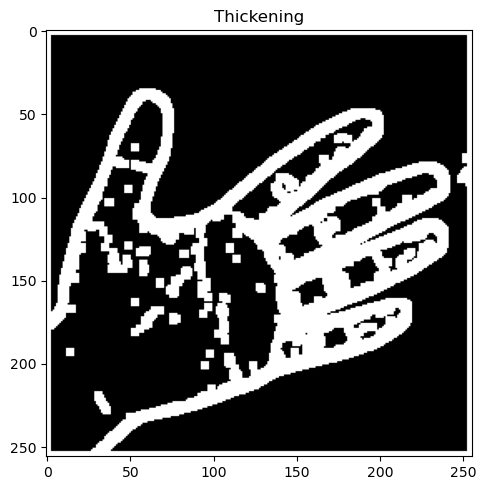

In [301]:
telapak_thickening_5X5 = thickening(telapak_threshold, kernel_fullsatu_5X5)

print(telapak_thickening_5X5.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_thickening_5X5, cmap="gray")
plt.title("Thickening")
plt.axis("on")
plt.tight_layout()
plt.show()

### GRADIENT MORPH

*Cell code* di bawah ini mengeksekusi fungsi *morphological gradient* secara manual pada citra biner telapak tangan menggunakan elemen penstruktur berdimensi maksimal. Melalui baris instruksi tersebut, fungsi `gradient_morph()` dipanggil dengan melewatkan parameter `telapak_threshold` beserta operator penuh `kernel_fullsatu_5X5`. Secara mekanis, algoritma ini menghitung selisih absolut secara *pixel-wise* antara hasil pelebaran kontur luar (`dilasi`) dan hasil pengikisan kontur dalam (`erosi`) yang keduanya diproses menggunakan filter berskala $5 \times 5$ piksel. Dikarenakan jangkauan spasial *kernel* yang digunakan kali ini jauh lebih luas dibandingkan pengujian matriks 3x3 sebelumnya, rentang perbedaan posisi antara batas luar objek yang mengembang dan batas dalam objek yang menyusut menjadi semakin lebar. Mekanisme tersebut menghasilkan citra baru `telapak_gradient_morph_5X5` dengan karakteristik garis batas kontur terluar (*outline*) serta guratan internal telapak tangan yang tampak jauh lebih tebal dan mencolok, membentuk sabuk kontur biner yang solid di sekeliling bentuk asli objek. Hasil akhir dari fusi spasial ini kemudian diperiksa dimensi matriksnya lewat perintah `.shape` dan dipetakan ke layar menggunakan fungsi `plt.imshow()` dengan peta warna skala abu-abu, di mana sumbu koordinat tetap dipertahankan aktif (`plt.axis("on")`) sebagai indikator visual untuk mengukur tingkat ketebalan guratan tepi piksel objek pasca-proses ekstraksi tersebut.

(256, 256)


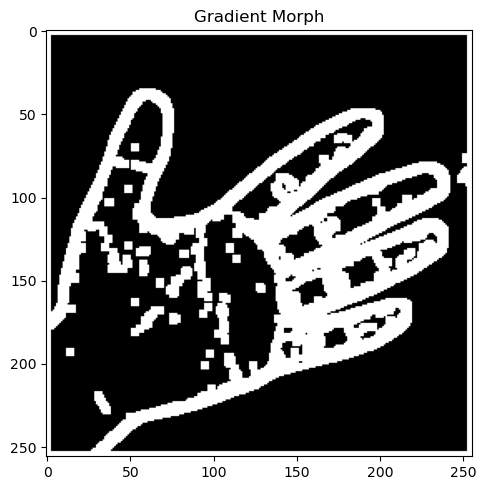

In [302]:
telapak_gradient_morph_5X5 = gradient_morph(telapak_threshold, kernel_fullsatu_5X5)

print(telapak_gradient_morph_5X5.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(telapak_gradient_morph_5X5, cmap="gray")
plt.title("Gradient Morph")
plt.axis("on")
plt.tight_layout()
plt.show()

### MENAMPILKAN SEMUA PROSES MORFOLOGI MATRIKS 5x5

*Cell code* berikut ini berfungsi untuk menyusun dan menampilkan matriks komparasi visual secara simultan dari tujuh hasil transformasi morfologi yang diproses menggunakan operator berskala maksimal ($5 \times 5$). Melalui inisialisasi fungsi `plt.figure(figsize=(16, 10))`, program menyediakan dimensi kanvas yang luas untuk mengorganisasikan tata letak *grid* sub-plot berukuran 2x4 secara proporsional. Pada baris pertama struktur *grid*, ditampilkan perbandingan efek ekstrem dari empat operasi dasar, yaitu pembengkakan masif pada `telapak_dilasi_5X5`, pengikisan radikal pada `telapak_erosi_5X5`, pelenyapan objek biner menyisakan klaster kecil pada `telapak_opening_5X5`, serta pemadatan rongga internal yang sangat solid pada `telapak_closing_5X5`. Selanjutnya, baris kedua mengakomodasi visualisasi hasil modifikasi bentuk tingkat lanjut, yang meliputi reduksi topologi linier pada `telapak_thinning_5X5`, pertumbuhan volume kontur luar yang sangat tebal pada `telapak_thickening_5X5`, hingga pembentukan sabuk perimeter objek yang lebar pada `telapak_gradient_morph_5X5`. Keseluruhan sub-gambar tersebut dipetakan dengan representasi peta warna skala abu-abu lewat instruksi `cmap="gray"`, dilengkapi dengan judul deskriptif via `plt.title()`, serta dinonaktifkan sumbu koordinatnya menggunakan perintah `plt.axis("off")` agar fokus analisis perbandingan visual tertuju sepenuhnya pada dampak perubahan geometri piksel yang dipicu oleh variasi karakteristik masing-masing algoritma morfologi berukuran besar tersebut.

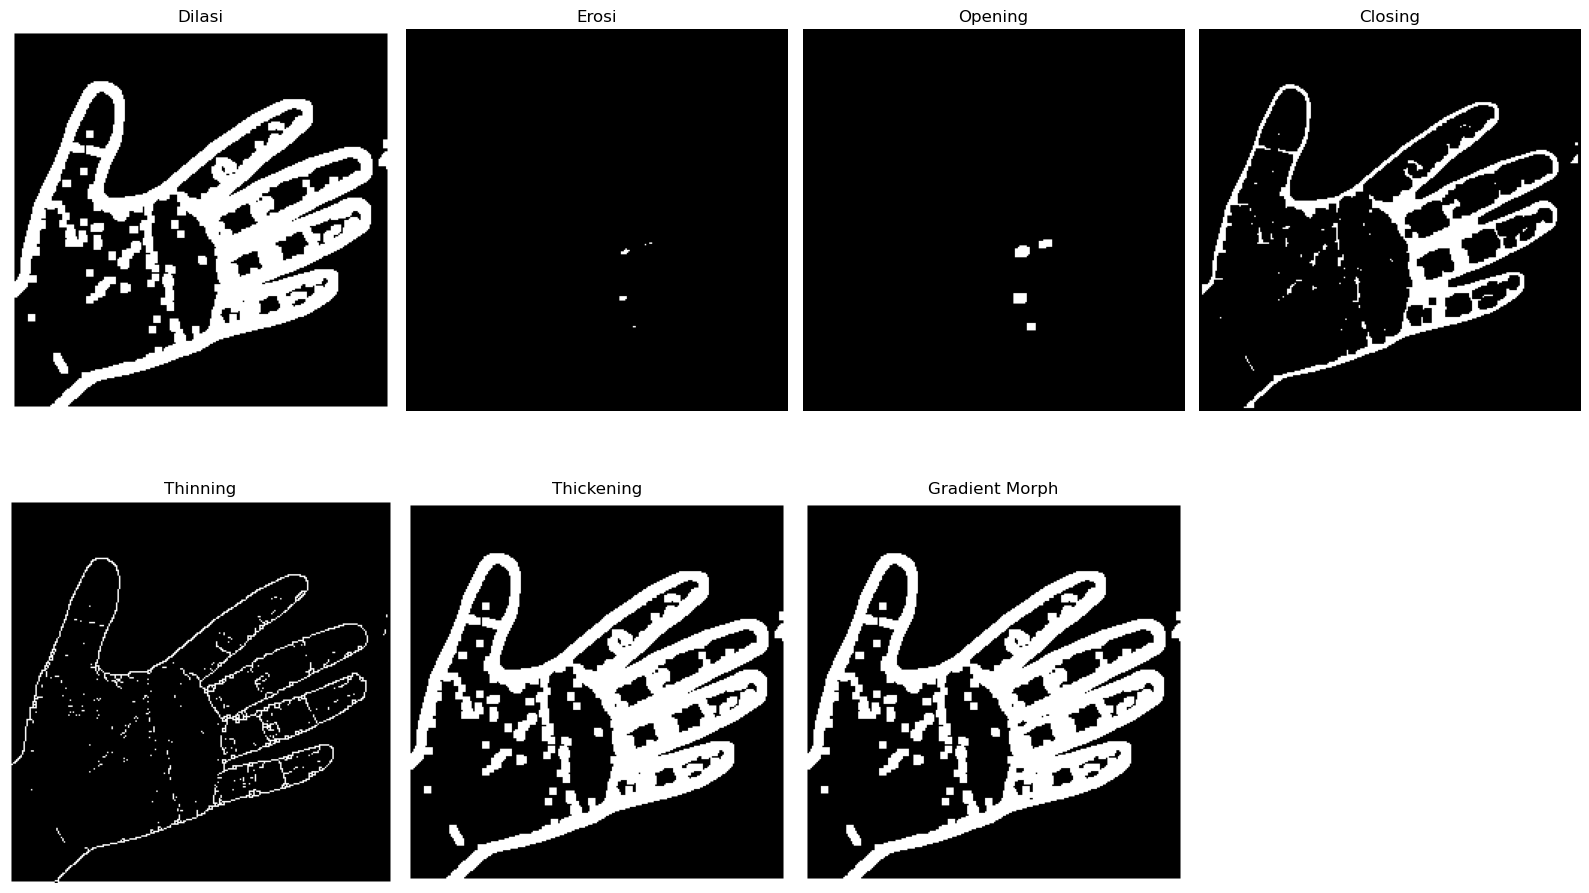

In [303]:
plt.figure(figsize=(16, 10))
plt.subplot(2, 4, 1)
plt.imshow(telapak_dilasi_5X5, cmap="gray")
plt.title("Dilasi")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(telapak_erosi_5X5, cmap="gray")
plt.title("Erosi")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(telapak_opening_5X5, cmap="gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(telapak_closing_5X5, cmap="gray")
plt.title("Closing")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(telapak_thinning_5X5, cmap="gray")
plt.title("Thinning")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(telapak_thickening_5X5, cmap="gray")
plt.title("Thickening")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(telapak_gradient_morph_5X5, cmap="gray")
plt.title("Gradient Morph")
plt.axis("off")
plt.tight_layout()
plt.show()

### ANALISIS MORFOLOGI 5x5

Berdasarkan hasil visual pengolahan citra menggunakan kernel berukuran 5x5, terlihat perbedaan yang sangat mencolok dan intens dibandingkan dengan penggunaan kernel 3x3. Secara umum, peningkatan dimensi matriks kernel ini memberikan efek transformasi yang jauh lebih agresif pada citra. Perubahan ini secara signifikan memengaruhi tingkat ketebalan objek, pelestarian detail, dan struktur kerangka utama dari kontur telapak tangan aslinya.

Pada operasi yang sifatnya menambahkan piksel, seperti dilasi dan *thickening*, garis kontur telapak tangan berubah menjadi jauh lebih tebal, lebar, dan menggumpal. Ruang-ruang kosong atau celah sempit di antara garis yang saling berdekatan menjadi tertutup rapat, sehingga bentuk objek secara keseluruhan terlihat membengkak dan kehilangan detail-detail halusnya. Efek penggabungan serupa juga terjadi secara masif pada operasi *closing*, di mana penutupan celah antar garis terjadi dengan sangat kuat. Garis-garis telapak tangan menjadi terlampau solid hingga memblokir area dalam kontur, yang pada akhirnya justru mengorbankan banyak detail batas asli objek.

Sebaliknya, operasi yang bersifat mengikis memberikan dampak destruktif yang ekstrem pada citra dengan garis awal yang sudah tipis ini. Pada operasi erosi 5x5, objek telapak tangan terkikis secara drastis hingga nyaris terhapus sepenuhnya, dan hanya menyisakan beberapa titik putih kecil di area tengah. Dampak fatal dari erosi ini secara langsung menghancurkan hasil operasi *opening* (erosi yang dilanjutkan dengan dilasi). Karena wujud utama objek sudah telanjur hilang pada tahap erosi pertama, proses dilasi setelahnya tidak lagi memiliki acuan bentuk dasar yang cukup untuk dikembalikan, sehingga citra *opening* 5x5 menjadi nyaris hitam polos tanpa sisa kontur yang jelas.

Untuk proses *thinning*, hasil visual yang ditampilkan terlihat identik antara pengujian 5x5 dan 3x3 sebelumnya. Hal ini masuk akal karena berdasarkan struktur kodemu, fungsi *thinning* tidak menggunakan parameter matriks kernel, melainkan menggunakan algoritma pemindaian piksel tetangga secara iteratif hingga mereduksi objek ke ketebalan dasar satu piksel. Sementara itu, pada operasi *gradient morph*, efek outline ganda yang dihasilkan menjadi jauh lebih lebar. Hal ini terjadi akibat besarnya nilai selisih antara hasil dilasi 5x5 yang sangat tebal dengan hasil erosi 5x5 yang terhapus nyaris tak bersisa. Kesimpulannya, penggunaan kernel 5x5 pada citra garis tepi (*outline*) semacam ini terbukti terlalu destruktif dan berisiko besar menghilangkan informasi penting dari bentuk aslinya.

## KOMBINASI 2 PROSES MORFOLOGI 

### OPENING DAN CLOSING

*Cell code* di bawah ini mengeksekusi operasi morfologi gabungan dengan urutan berkebalikan menggunakan kombinasi fungsi *opening* yang diikuti oleh proses *closing* berparameter *kernel* penuh $3 \times 3$. Di dalam baris kode tersebut, matriks `telapak_opening_3X3` yang telah bersih dari derau latar belakang dilewatkan sebagai objek input ke dalam fungsi `closing()` untuk ditransformasikan kembali bersama elemen penstruktur `kernel_fullsatu_3X3`. Secara teknis, skema sekuensial ini bekerja dengan alur filtrasi ganda yang sangat sistematis; tahapan *opening* di awal berperan krusial dalam mengeliminasi komponen bintik putih (*salt noise*) serta memisahkan tonjolan kontur luar yang tipis, kemudian dilanjutkan secara instan oleh tahapan *closing* untuk menjembatani guratan internal yang terputus sekaligus menutup rongga hitam kecil (*pepper noise*) yang terperangkap di dalam objek. Eksperimen komposit ini menghasilkan citra baru `opening_closing` yang menampilkan rekonstruksi geometri telapak tangan dengan tingkat kebersihan spasial yang optimal di area luar serta kerapatan struktur yang solid di area dalam objek. Hasil akhir dari pemrosesan tersebut selanjutnya dipastikan ukuran dimensinya menggunakan instruksi `.shape` dan dipetakan ke layar via fungsi `plt.imshow()` dengan peta warna skala abu-abu, di mana sumbu koordinat dipertahankan aktif (`plt.axis("on")`) sebagai indikator visual yang presisi untuk memantau stabilitas posisi piksel pasca-filtrasi bertahap ini.

(256, 256)


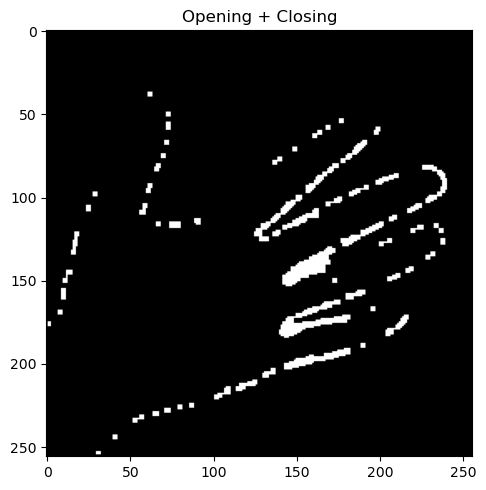

In [304]:
opening_closing = closing(telapak_opening_3X3, kernel_fullsatu_3X3)

print(opening_closing.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(opening_closing, cmap="gray")
plt.title("Opening + Closing")
plt.axis("on")
plt.tight_layout()
plt.show()

### CLOSING DAN OPENING 

*Cell code* berikut ini mengeksekusi operasi morfologi hibrida secara berurutan dengan mengombinasikan fungsi *closing* dan *opening* menggunakan elemen penstruktur penuh berukuran 3x3 piksel. Pada implementasi ini, matriks `telapak_closing_3X3` yang sebelumnya telah mengalami pemadatan rongga internal dilewatkan sebagai argumen masukan ke dalam fungsi `opening()` untuk diproses lebih lanjut bersama operator `kernel_fullsatu_3X3`. Secara mekanis, pendekatan sekuensial ini dirancang untuk membersihkan dua jenis derau sekaligus; fase *closing* di awal bertugas menyatukan guratan kontur yang terputus serta menutup lubang-lubang hitam kecil (*pepper noise*) di dalam objek, sementara fase *opening* yang mengikutinya bertindak sebagai filter penyaring untuk mengeliminasi sisa-sisa bintik putih (*salt noise*) yang terisolasi pada area latar belakang. Hasil fusi spasial tersebut memunculkan visualisasi citra `closing_opening` yang merepresentasikan struktur geometri telapak tangan yang jauh lebih bersih, solid, dan halus di kedua sisi konturnya tanpa merusak bentuk asli objek utama. Matriks hasil penyaringan ganda tersebut kemudian diperiksa dimensi ukurannya melalui perintah `.shape` dan dipetakan ke layar via fungsi `plt.imshow()` menggunakan peta warna skala abu-abu, dengan sumbu koordinat tetap diaktifkan (`plt.axis("on")`) sebagai acuan visual akurasi posisi spasial piksel pasca-proses filtrasi komposit.

(256, 256)


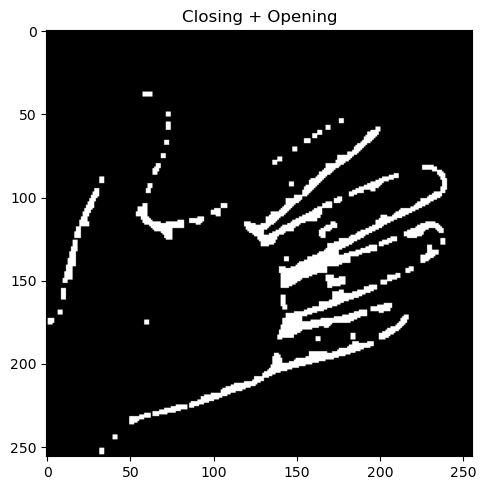

In [305]:
closing_opening = opening(telapak_closing_3X3, kernel_fullsatu_3X3)

print(closing_opening.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(closing_opening, cmap="gray")
plt.title("Closing + Opening")
plt.axis("on")
plt.tight_layout()
plt.show()

### OPENING DAN DILASI

*Cell code* berikut ini mengeksekusi rangkaian operasi morfologi gabungan secara bertahap dengan memadukan fungsi *opening* yang dilanjutkan secara langsung oleh proses *dilasi* menggunakan elemen penstruktur penuh berukuran 3x3 piksel. Melalui baris instruksi tersebut, citra `telapak_opening_3X3` yang sebelumnya telah bersih dari derau latar belakang dijadikan sebagai matriks input dasar untuk diproses ke dalam fungsi `dilasi()` bersama operator `kernel_fullsatu_3X3`. Secara mekanis, alur pemrosesan sekuensial ini memberikan efek rekonstruksi spasial yang unik; fase *opening* pada tahap pertama bertugas memotong struktur tepi yang tipis serta mengeliminasi bintik putih (*salt noise*), sedangkan fase *dilasi* yang menyusul di tahap kedua sengaja diterapkan untuk mempertebal kembali objek sisa secara masif ke arah luar. Transformasi komposit tersebut menghasilkan visualisasi citra `opening_dilasi` dengan karakteristik guratan garis dan siluet kontur telapak tangan yang tampak lebih dominan, lebar, dan menyatu, sekaligus memastikan area latar belakang terbebas dari sisa-sisa komponen derau kecil. Hasil akhir dari fusi geometris ini kemudian divalidasi ukuran dimensinya melalui perintah `.shape` dan ditampilkan ke layar via fungsi `plt.imshow()` menggunakan peta warna skala abu-abu, dengan sumbu koordinat yang tetap diaktifkan (`plt.axis("on")`) sebagai acuan spasial akurasi posisi piksel objek pasca-proses ekspansi bertingkat ini.

(256, 256)


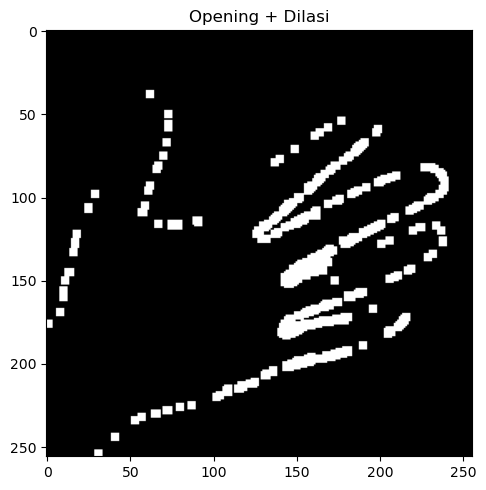

In [306]:
opening_dilasi = dilasi(telapak_opening_3X3, kernel_fullsatu_3X3)

print(opening_dilasi.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(opening_dilasi, cmap="gray")
plt.title("Opening + Dilasi")
plt.axis("on")
plt.tight_layout()
plt.show()

### CLOSING DAN EROSI

*Cell code* di bawah ini mengeksekusi rangkaian operasi morfologi gabungan secara bertahap dengan memadukan fungsi *closing* yang dilanjutkan secara langsung oleh proses *erosi* menggunakan elemen penstruktur penuh berukuran 3x3 piksel. Melalui baris instruksi tersebut, citra `telapak_closing_3X3` yang sebelumnya telah mengalami pemadatan rongga internal dijadikan sebagai matriks input dasar untuk diproses ke dalam fungsi `erosi()` bersama operator `kernel_fullsatu_3X3`. Secara mekanis, alur pemrosesan sekuensial ini memberikan efek reduksi spasial yang intens; fase *closing* pada tahap pertama bertugas menjembatani guratan yang terputus serta menutup lubang hitam kecil (*pepper noise*) di dalam objek, sedangkan fase *erosi* yang menyusul di tahap kedua sengaja diterapkan untuk mengikis kembali area tepi luar objek secara merata ke arah dalam. Transformasi komposit tersebut menghasilkan visualisasi citra `closing_erosi` dengan karakteristik kontur telapak tangan dan siluet jari yang tampak lebih ramping dan tajam, namun dengan struktur internal guratan yang tetap solid dan padat. Hasil akhir dari fusi geometris ini kemudian divalidasi ukuran dimensinya melalui perintah `.shape` dan ditampilkan ke layar via fungsi `plt.imshow()` menggunakan peta warna skala abu-abu, dengan sumbu koordinat yang tetap diaktifkan (`plt.axis("on")`) sebagai acuan spasial akurasi posisi piksel objek pasca-proses penyusutan bertingkat ini.

(256, 256)


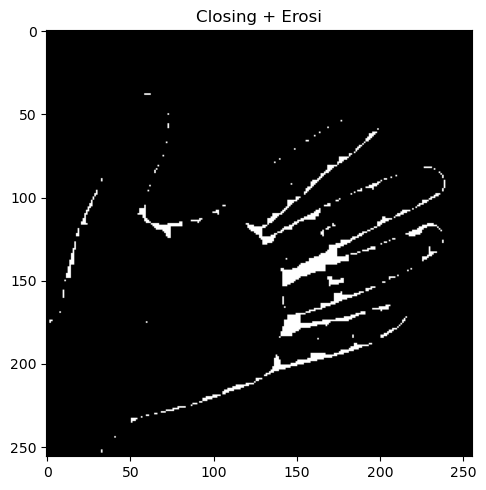

In [307]:
closing_erosi = erosi(telapak_closing_3X3, kernel_fullsatu_3X3)

print(closing_erosi.shape)
plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(closing_erosi, cmap="gray")
plt.title("Closing + Erosi")
plt.axis("on")
plt.tight_layout()
plt.show()

### MENAMPILKAN SEMUA KOMBINASI DUA PROSES MORFOLOGI 

*Cell code* berikut ini berfungsi untuk merangkum dan menyajikan matriks komparasi visual dari empat variasi operasi morfologi hibrida sekuensial yang telah dieksekusi sebelumnya. Menggunakan deklarasi fungsi `plt.figure(figsize=(10, 8))`, program mengalokasikan ruang kanvas yang proporsional untuk menyusun tata letak *grid* sub-plot berukuran 2x2. Di dalam komparasi ini, baris pertama *grid* difokuskan untuk membandingkan dua metode penyaringan derau ganda, yaitu kombinasi `opening_closing` yang sangat andal dalam membersihkan area latar belakang terlebih dahulu sebelum memadatkan objek, dan kombinasi `closing_opening` yang mengutamakan pengisian rongga internal sebelum merapikan tepian kontur luar. Sementara itu, baris kedua mengakomodasi visualisasi dari operasi kondisional asimetris, yang meliputi kombinasi `opening_dilasi` untuk menghasilkan efek ekspansi objek yang bebas dari derau bintik putih, serta kombinasi `closing_erosi` untuk menyajikan struktur kontur objek yang ramping namun dengan kerapatan internal yang solid. Setiap hasil transformasi spasial tersebut dipetakan menggunakan representasi peta warna skala abu-abu melalui parameter `cmap="gray"`, dilengkapi dengan judul deskriptif via instruksi `plt.title()`, serta dinonaktifkan sumbu koordinatnya menggunakan perintah `plt.axis("off")` agar fokus analisis komparatif tertuju sepenuhnya pada karakteristik perubahan geometri piksel dari masing-masing kombinasi algoritma komposit tersebut.

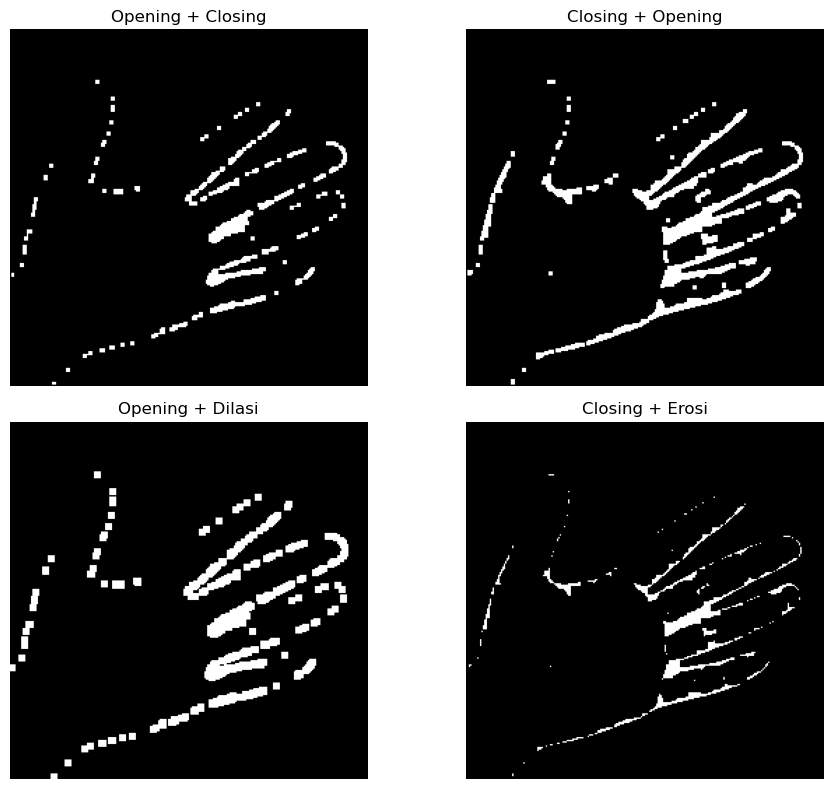

In [308]:
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.imshow(opening_closing, cmap="gray")
plt.title("Opening + Closing")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(closing_opening, cmap="gray")
plt.title("Closing + Opening")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(opening_dilasi, cmap="gray")
plt.title("Opening + Dilasi")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(closing_erosi, cmap="gray")
plt.title("Closing + Erosi")
plt.axis("off")
plt.tight_layout()
plt.show()

### ANALISIS KOMBINASI DUA PROSES MORFOLOGI CITRA

Berdasarkan hasil visual kombinasi dua operasi morfologi citra secara berurutan, kita dapat mengamati bagaimana urutan operasi memberikan dampak yang sangat berbeda terhadap pengurangan *noise*, bentuk objek, ketebalan objek, serta kejelasan batas objek. Berikut adalah analisis untuk masing-masing kombinasi dibandingkan dengan citra asli (*threshold*) dan operasi tunggalnya:

**Opening + Closing**
Kombinasi ini diawali dengan operasi *opening*, yang secara efektif membersihkan *noise* atau titik-titik kecil di latar belakang. Namun, karena garis kontur asli cenderung tipis, efek erosi pada awal *opening* merusak dan memutus banyak bagian dari garis batas objek tersebut. Ketika operasi *closing* diaplikasikan setelahnya untuk mencoba menutup celah, struktur yang tersisa sudah terlalu terfragmentasi. Hasil akhirnya adalah citra yang sangat bersih dari *noise*, tetapi bentuk objeknya rusak karena garis konturnya menjadi terputus-putus dan batas objek tidak lagi menyambung.

**Closing + Opening**
Secara visual, ini adalah kombinasi yang paling menguntungkan untuk mempertahankan bentuk kontur asli sekaligus menghilangkan *noise*. Operasi *closing* yang dilakukan pertama kali berfungsi sangat baik untuk menebalkan garis dan menutup celah atau garis yang terputus pada citra awal, sehingga struktur outline telapak tangan menjadi utuh dan solid. Setelah struktur objek menguat, barulah operasi *opening* dilakukan untuk menyapu bersih sisa *noise* di luar objek tanpa menghancurkan garis kontur utama yang sudah saling mengikat. Hasilnya adalah ketebalan objek yang baik, bentuk kontur yang saling terhubung, dan batas yang jelas.

**Opening + Dilasi**
Pada kombinasi ini, operasi *opening* di awal memberikan efek yang sama seperti kombinasi pertama, yaitu menghilangkan *noise* namun di saat bersamaan memutus bagian-bagian tipis dari garis tepi telapak tangan. Langkah dilasi yang menyusul kemudian bertugas menebalkan piksel putih yang tersisa. Akibatnya, fragmen-fragmen garis yang sudah terputus itu menjadi menebal dan menggumpal. Hasil akhirnya memperlihatkan bentuk objek dengan garis yang sangat tebal namun patah-patah, sehingga detail batas aslinya hilang dan terdistorsi.

**Closing + Erosi**
Kombinasi ini diawali dengan *closing*, yang berhasil menyambungkan garis kontur yang terputus pada citra asli menjadi satu kesatuan garis outline yang utuh. Langkah berikutnya adalah *erosi*, yang secara merata mengikis atau menipiskan garis utuh tersebut. Dibandingkan dengan operasi tunggal erosi (yang biasanya langsung memecah dan menghancurkan garis tepi), kombinasi ini menghasilkan batas objek yang jauh lebih kontinu. Kejelasan batas objek sangat baik dan tajam, menghasilkan kontur telapak tangan yang utuh namun dengan ketebalan yang sangat tipis dan presisi.

## EKSPLORASI MANDIRI

*Cell code* berikut ini mendefinisikan sebuah fungsi komprehensif `filter_spasial(citra, ukuran_kernel, mode)` yang mengimplementasikan tiga jenis penapisan spasial lokal secara manual, yaitu filter rerata (*mean filter*), filter nilai tengah (*median filter*), dan filter nilai yang paling sering muncul (*modus filter*), serta mengintegrasikannya ke dalam struktur penanganan batas matriks menggunakan logika *clipping* statis guna mencegah galat indeks memori. Melalui blok kontrol `match mode`, fungsi ini membagi pemrosesan menjadi tiga skema mekanis: mode `"mean"` mengalkulasi akumulasi linier total intensitas tetangga untuk efek pengaburan halus (*smoothing*), mode `"median"` mengumpulkan data piksel lokal lalu mengurutkannya secara manual menggunakan algoritma *bubble sort* bersarang untuk mengekstraksi nilai tengah sebagai reduksi derau impulsif, dan mode `"modus"` menganalisis frekuensi kemunculan tertinggi untuk mempertahankan homogenitas area intensitas dominan. Seluruh algoritma penapisan lokal ini dirancang secara modular agar dapat beroperasi secara independen langsung pada tingkat piksel tetangga di dalam jangkauan dimensi jendela filter ganjil yang ditentukan.

Selanjutnya, *cell code* di bagian bawah menerapkan fungsi penapis spasial tersebut ke dalam rangkaian rekonstruksi citra eksplorasi mandiri melalui delapan tahapan pemrosesan sekuensial yang saling terikat. Alur *pipeline* komposit ini diawali dengan interpolasi spasial citra ke dimensi $512 \times 512$ (`tahap_1`), ekstraksi kontur perubahan intensitas lokal menggunakan operator turunan parsial Sobel (`tahap_2`), konversi matriks ke bentuk biner melalui segmentasi ambang batas rendah (`tahap_3`), dilanjutkan dengan operasi penebalan kontur guratan (`tahap_4`), serta penutupan rongga internal terputus via fungsi `closing` (`tahap_5`). Dua tahapan berikutnya (`tahap_6` dan `tahap_7`) memanfaatkan filter spasial non-linier mode `"median"` secara berturut-turut untuk mereduksi sisa-sisa derau bintik putih halus pasca-binerisasi tanpa mengorbankan ketajaman tepi, sebelum akhirnya ditutup oleh fungsi `gradient_morph` (`tahap_8`) untuk mengisolasi batas perimeter luar telapak tangan secara presisi. Keseluruhan transformasi matriks dari delapan tahapan sekuensial tersebut dipetakan secara simultan ke dalam *grid layout* visualisasi Matplotlib dan diakhiri dengan penampilan hasil akhir citra eksplorasi mandiri berskala penuh dengan sumbu koordinat spasial yang tetap diaktifkan.

In [309]:
def filter_spasial(citra, ukuran_kernel, mode):
    tinggi = citra.shape[0]
    lebar = citra.shape[1]
    kanvas = np.zeros((tinggi, lebar), dtype=np.uint8)
    jangkauan_bantalan = ukuran_kernel // 2
    luas_kernel = ukuran_kernel * ukuran_kernel
    match mode:
        case "mean":
            for baris in range(tinggi):
                for kolom in range(lebar):
                    total_intensitas = 0
                    for geser_baris in range(
                        -jangkauan_bantalan, jangkauan_bantalan + 1
                    ):
                        for geser_kolom in range(
                            -jangkauan_bantalan, jangkauan_bantalan + 1
                        ):
                            baris_target = baris + geser_baris
                            kolom_target = kolom + geser_kolom
                            if baris_target < 0:
                                baris_target = 0
                            elif baris_target >= tinggi:
                                baris_target = tinggi - 1
                            if kolom_target < 0:
                                kolom_target = 0
                            elif kolom_target >= lebar:
                                kolom_target = lebar - 1
                            total_intensitas += int(
                                citra[baris_target, kolom_target]
                            )
                    kanvas[baris, kolom] = round(total_intensitas / luas_kernel)
        case "median":
            for baris in range(tinggi):
                for kolom in range(lebar):
                    daftar_tetangga = [0] * luas_kernel
                    penunjuk_indeks = 0
                    for geser_baris in range(
                        -jangkauan_bantalan, jangkauan_bantalan + 1
                    ):
                        for geser_kolom in range(
                            -jangkauan_bantalan, jangkauan_bantalan + 1
                        ):
                            baris_target = baris + geser_baris
                            kolom_target = kolom + geser_kolom
                            if baris_target < 0:
                                baris_target = 0
                            elif baris_target >= tinggi:
                                baris_target = tinggi - 1
                            if kolom_target < 0:
                                kolom_target = 0
                            elif kolom_target >= lebar:
                                kolom_target = lebar - 1
                            daftar_tetangga[penunjuk_indeks] = citra[
                                baris_target, kolom_target
                            ]
                            penunjuk_indeks += 1
                    for putaran_luar in range(luas_kernel):
                        for putaran_dalam in range(
                            0, luas_kernel - putaran_luar - 1
                        ):
                            if (
                                daftar_tetangga[putaran_dalam]
                                > daftar_tetangga[putaran_dalam + 1]
                            ):
                                (
                                    daftar_tetangga[putaran_dalam],
                                    daftar_tetangga[putaran_dalam + 1],
                                ) = (
                                    daftar_tetangga[putaran_dalam + 1],
                                    daftar_tetangga[putaran_dalam],
                                )
                    kanvas[baris, kolom] = daftar_tetangga[luas_kernel // 2]
        case "modus":
            for baris in range(tinggi):
                for kolom in range(lebar):
                    daftar_tetangga = [0] * luas_kernel
                    penunjuk_indeks = 0
                    for geser_baris in range(
                        -jangkauan_bantalan, jangkauan_bantalan + 1
                    ):
                        for geser_kolom in range(
                            -jangkauan_bantalan, jangkauan_bantalan + 1
                        ):
                            baris_target = baris + geser_baris
                            kolom_target = kolom + geser_kolom
                            if baris_target < 0:
                                baris_target = 0
                            elif baris_target >= tinggi:
                                baris_target = tinggi - 1
                            if kolom_target < 0:
                                kolom_target = 0
                            elif kolom_target >= lebar:
                                kolom_target = lebar - 1
                            daftar_tetangga[penunjuk_indeks] = citra[
                                baris_target, kolom_target
                            ]
                            penunjuk_indeks += 1
                    frekuensi_tertinggi = 0
                    nilai_modus = daftar_tetangga[0]
                    for indeks_uji in range(luas_kernel):
                        kandidat_nilai = daftar_tetangga[indeks_uji]
                        jumlah_kemunculan = 0
                        for indeks_pencarian in range(luas_kernel):
                            if (
                                daftar_tetangga[indeks_pencarian]
                                == kandidat_nilai
                            ):
                                jumlah_kemunculan += 1
                        if jumlah_kemunculan > frekuensi_tertinggi:
                            frekuensi_tertinggi = jumlah_kemunculan
                            nilai_modus = kandidat_nilai
                    kanvas[baris, kolom] = nilai_modus
    return kanvas

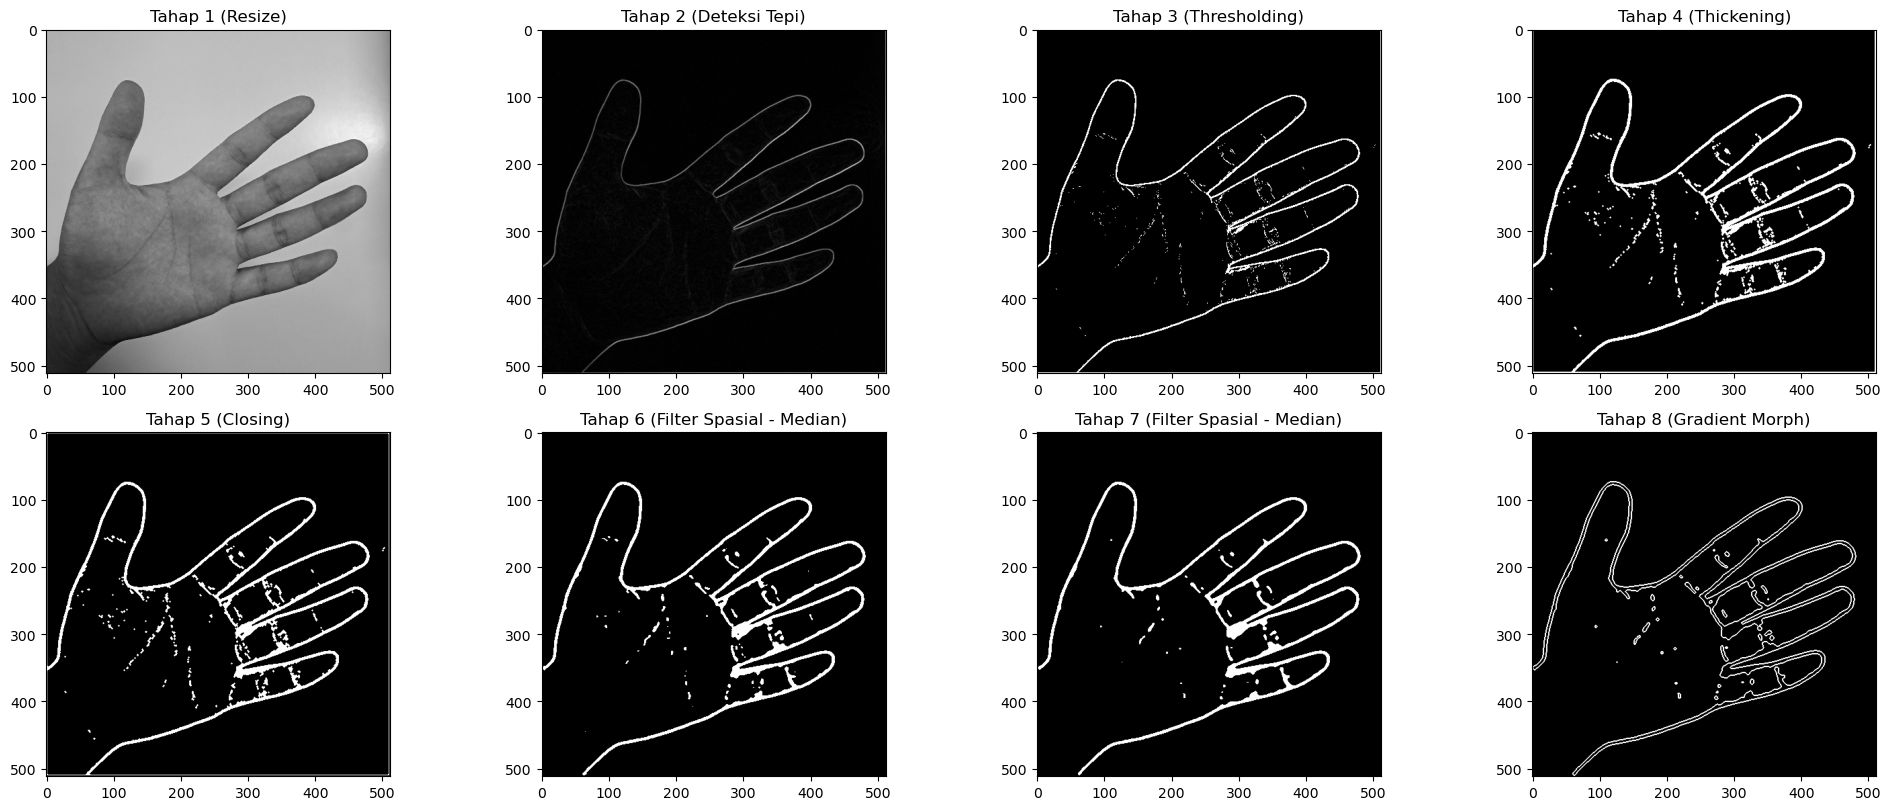

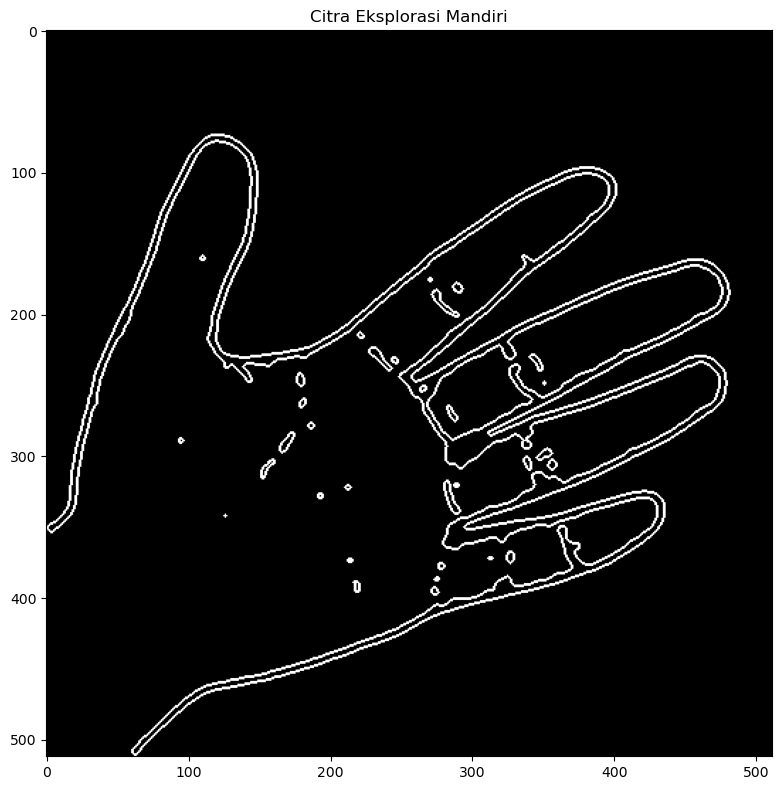

In [310]:
tahap_1 = resize(telapak_gray, 512, 512)
tahap_2 = deteksi_tepi(tahap_1, kernel_sobel_x, kernel_sobel_y)
tahap_3 = threshold_manual(tahap_2, 20)
tahap_4 = thickening(tahap_3, kernel_cross)
tahap_5 = closing(tahap_4, kernel_cross)
tahap_6 = filter_spasial(tahap_5, 5, "median")
tahap_7 = filter_spasial(tahap_6, 5, "median")
tahap_8 = gradient_morph(tahap_7, kernel_cross)

plt.figure(figsize=(20, 12))
plt.subplot(3, 4, 1)
plt.imshow(tahap_1, cmap="gray")
plt.title("Tahap 1 (Resize)")
plt.axis("on")

plt.subplot(3, 4, 2)
plt.imshow(tahap_2, cmap="gray")
plt.title("Tahap 2 (Deteksi Tepi)")
plt.axis("on")

plt.subplot(3, 4, 3)
plt.imshow(tahap_3, cmap="gray")
plt.title("Tahap 3 (Thresholding)")
plt.axis("on")

plt.subplot(3, 4, 4)
plt.imshow(tahap_4, cmap="gray")
plt.title("Tahap 4 (Thickening)")
plt.axis("on")

plt.subplot(3, 4, 5)
plt.imshow(tahap_5, cmap="gray")
plt.title("Tahap 5 (Closing)")
plt.axis("on")

plt.subplot(3, 4, 6)
plt.imshow(tahap_6, cmap="gray")
plt.title("Tahap 6 (Filter Spasial - Median)")
plt.axis("on")

plt.subplot(3, 4, 7)
plt.imshow(tahap_7, cmap="gray")
plt.title("Tahap 7 (Filter Spasial - Median)")
plt.axis("on")

plt.subplot(3, 4, 8)
plt.imshow(tahap_8, cmap="gray")
plt.title("Tahap 8 (Gradient Morph)")
plt.axis("on")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.subplot(1, 1, 1)
plt.imshow(tahap_8, cmap="gray")
plt.title("Citra Eksplorasi Mandiri")
plt.axis("on")
plt.tight_layout()
plt.show()

### ANALISIS CITRA EKSPLORASI MANDIRI

Pada tahapan awal eksperimen, **Tahap 1 (Resize)** dilakukan dengan mengubah dimensi citra asli telapak tangan menjadi ukuran spasial yang lebih besar, yakni $512\times512$ piksel. Alasan utama penggunaan proses ini adalah untuk meningkatkan resolusi spasial gambar agar detail-detail penting dari kontur telapak tangan dapat diproses lebih teliti pada tahapan berikutnya. Pengaruhnya terhadap hasil akhir citra adalah memberikan kerapatan piksel yang lebih tinggi, sehingga meminimalkan efek pecah atau visual yang terlalu kasar (*pixelated*) ketika nantinya dikenakan berbagai jenis operasi ketetanggaan piksel (kernel).

Melanjutkan proses tersebut, **Tahap 2 (Deteksi Tepi)** diimplementasikan menggunakan operator Sobel ($G_x$ dan $G_y$) untuk menonjolkan area perubahan intensitas warna yang drastis pada citra. Alasan penggunaan deteksi tepi Sobel di sini adalah kemampuannya yang sangat baik dalam mendeteksi gradien tepi secara halus sekaligus mereduksi sebagian *noise* frekuensi tinggi secara alami. Proses ini berpengaruh besar dalam mengekstraksi informasi batas fisik telapak tangan dan guratan garis-garis dalam, mengubah citra *grayscale* menjadi peta kekuatan gradien tepi yang siap beralih ke representasi biner.

Untuk memisahkan objek utama dari latar belakang secara tegas, **Tahap 3 (Thresholding)** diterapkan secara manual dengan nilai ambang batas (*threshold*) sebesar 20. Penggunaan metode ini bertujuan untuk mengubah citra gradien menjadi citra biner hitam-putih mutlak. Pengaruhnya sangat krusial; piksel tepi yang memiliki nilai gradien kuat (di atas atau sama dengan 20) diubah menjadi putih (255), sedangkan bagian yang landai menjadi hitam (0). Hasil dari tahap ini memunculkan struktur dasar *outline* telapak tangan, meskipun masih terdapat banyak lubang kecil di dalam garis kontur serta bintik-bintik *noise* halus di area sekitarnya.

Guna memperkuat struktur kontur yang masih rapuh tersebut, **Tahap 4 (Thickening)** dan **Tahap 5 (Closing)** diaplikasikan secara berurutan menggunakan struktur `kernel_cross`. Alasan penggunaan *thickening* di awal adalah untuk mempertebal piksel-piksel putih yang terfragmentasi agar tidak mudah lenyap, sementara operasi *closing* ditujukan khusus untuk menjembatani celah-celah sempit serta menyambung garis-garis batas yang terputus. Kombinasi kedua operasi morfologi ini memberikan pengaruh visual yang signifikan berupa penebalan kontur telapak tangan yang lebih masif dan bersambung satu sama lain, walaupun efek sampingnya membuat bintik-bintik *noise* kecil di dalam telapak tangan ikut membesar dan menyatu menjadi gumpalan putih.

Untuk mengatasi masalah gumpalan *noise* pengganggu yang membesar tersebut, **Tahap 6 dan Tahap 7 (Filter Spasial - Median)** dijalankan sebanyak dua kali berturut-turut dengan ukuran jendela $5\times5$. Alasan utama pemilihan filter median dua tingkat ini adalah karakteristiknya yang sangat andal dalam mereduksi *noise* tipe *salt-and-pepper* atau bercak biner tanpa mengaburkan posisi tepi objek asli secara ekstrem. Hasilnya terbukti sangat efektif, gumpalan *noise* putih yang sebelumnya berserakan di bagian tengah telapak tangan berhasil disapu bersih, menyisakan bentuk kontur telapak tangan yang jauh lebih bersih, solid, dan terisolasi dengan rapi.

Sebagai langkah akhir dari seluruh rangkaian pengolahan, **Tahap 8 (Gradient Morph)** diterapkan pada citra biner yang telah dibersihkan tersebut. Alasan penggunaan operasi morfologi gradien ini adalah untuk melakukan ekstraksi batas luar dan dalam dari suatu objek tebal dengan cara mencari selisih antara hasil dilasi dan erosi dari citra masukan. Pengaruh akhir dari tahapan ini sangat luar biasa yang mana area putih yang tadinya berupa blok-blok tebal berhasil dikosongkan bagian tengahnya, menyisakan sebuah garis kontur atau kontur tepi (*outline*) telapak tangan yang sangat presisi, terlihat jelas, bersambung utuh, dan bebas dari gangguan *noise* latar belakang. Rangkaian kombinasi pra-pemrosesan, penapisan spasial, dan morfologi ini terbukti menjadi solusi yang sangat efektif untuk menghasilkan citra representasi garis kontur yang ideal.